# Shortcut Learning in Risky-Intent Classification


## Experiment List

| ID | Experiment |
|---|---|
| E1 | RoBERTa Fine-Tuned Baseline |
| E2 | RoBERTa + Keyword Masking |
| E3 | RoBERTa + Counterfactual Augmentation |
| E4 | RoBERTa + Keyword Masking + Counterfactual Augmentation |
| E5 | RoBERTa + Experience Replay |
| E6 | NLI Zero-Shot |
| E7 | NLI Fine-Tuned |
| E8 | NLI + Keyword Masking + Counterfactual Augmentation |
| E9 | NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation |

Each experiment shows:

- Metrics
- Classification report
- Confusion matrix
- OOD category performance
- Wrong examples
- Confident wrong examples
- SHAP analysis on three fixed sentences when applicable

Fixed SHAP sentences:

```python
sentences = [
    "I eat ice cream.",
    "I cut myself.",
    "I want to die to make everyone happy in this house.",
]

# 1. Clone Repository and Setup

This section is for running the notebook on a fresh Colab or GPU instance.

If the notebook is already inside the repository, skip the `git clone` command and only run the installation.

In [1]:
!git clone https://github.com/juliairsalina/shortcut-learning-risky-intent.git
%cd shortcut-learning-risky-intent
!pip install -r requirements.txt

Cloning into 'shortcut-learning-risky-intent'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 97 (delta 40), reused 71 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 797.89 KiB | 41.99 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/home/ubuntu/shortcut-learning-risky-intent
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 132.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 146.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 136.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 42.4 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 65.4 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 125.4 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Training may be slow.")

CUDA available: True
GPU: NVIDIA L4


# 2. Imports, Paths, and Global Settings

In [3]:
from pathlib import Path
import json
import random
import subprocess
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display, Image

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 80)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA L4


In [27]:
ROOT = Path(".")

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
PRED_DIR = RESULTS_DIR / "predictions"
PLOTS_DIR = RESULTS_DIR / "plots"
SHAP_DIR = RESULTS_DIR / "shap"

SAVED_MODELS_DIR = ROOT / "saved_models"

for folder in [
    PROCESSED_DIR,
    METRICS_DIR,
    PRED_DIR,
    PLOTS_DIR,
    SHAP_DIR,
    SAVED_MODELS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "train.csv"
VAL_PATH = PROCESSED_DIR / "val.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"
OOD_PATH = PROCESSED_DIR / "ood.csv"

TRAIN_MASKED_PATH = PROCESSED_DIR / "train_masked.csv"
TRAIN_COUNTERFACTUAL_PATH = PROCESSED_DIR / "train_counterfactual.csv"
TRAIN_FULL_PATH = PROCESSED_DIR / "train_full.csv"
REPLAY_PATH = PROCESSED_DIR / "replay_examples.csv"

ROBERTA_MODEL = "roberta-base"
NLI_MODEL = "cross-encoder/nli-roberta-base"

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

LABEL_MAP = {
    0: "non-risky",
    1: "risky",
}

LABEL_TO_ID = {
    "non-risky": 0,
    "risky": 1,
    0: 0,
    1: 1,
}

SHAP_SENTENCES = [
    "I don't want to die.",
    "I won't cut myself.",
    "I want to die to make everyone happy in this house.",
]

# 3. File Check

In [5]:
required_files = [
    RAW_DIR / "dataset_nad.xlsx",
    RAW_DIR / "custom_ood_set_150_julia.csv",
    Path("src/data_utils.py"),
    Path("src/masking.py"),
    Path("src/augmentation.py"),
]

print("File check:")

for path in required_files:
    if path.exists():
        print(f"FOUND   : {path}")
    else:
        print(f"MISSING : {path}")

File check:
FOUND   : data/raw/dataset_nad.xlsx
FOUND   : data/raw/custom_ood_set_150_julia.csv
FOUND   : src/data_utils.py
FOUND   : src/masking.py
FOUND   : src/augmentation.py


# 4. Helper Functions

In [28]:
def run_command(command):
    print("=" * 80)
    print(command)
    print("=" * 80)

    result = subprocess.run(command, shell=True)

    if result.returncode != 0:
        print(f"WARNING: Command failed: {command}")

    return result.returncode


def load_csv(path):
    path = Path(path)

    if not path.exists():
        print(f"WARNING: Missing CSV file: {path}")
        return None

    return pd.read_csv(path)


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)


def load_json(path):
    path = Path(path)

    if not path.exists():
        print(f"WARNING: Missing JSON file: {path}")
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_label_column(df):
    df = df.copy()

    if "gold_label" in df.columns and "label" not in df.columns:
        df["label"] = df["gold_label"]

    if "label" not in df.columns:
        raise ValueError("Dataset must contain label or gold_label column.")

    df["label"] = df["label"].map(
        lambda x: LABEL_TO_ID[x] if x in LABEL_TO_ID else int(x)
    )

    df["label"] = df["label"].astype(int)

    return df


def show_dataset_overview(name, df):
    if df is None:
        return

    print("=" * 80)
    print(name)
    print("=" * 80)

    print("Shape:", df.shape)
    display(df.head())

    if "label" in df.columns:
        label_counts = df["label"].map(LABEL_MAP).value_counts().reset_index()
        label_counts.columns = ["label", "count"]
        display(label_counts)

    if "category" in df.columns:
        cat_counts = df["category"].value_counts().reset_index()
        cat_counts.columns = ["category", "count"]
        display(cat_counts)


def print_experiment_header(title):
    print("\n")
    print("=" * 80)
    print(f"  {title}")
    print("=" * 80)


def print_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {weighted_f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["non-risky", "risky"],
            zero_division=0,
        )
    )

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=["non-risky", "risky"],
            output_dict=True,
            zero_division=0,
        ),
    }


def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["non-risky", "risky"])
    plt.yticks([0, 1], ["non-risky", "risky"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return cm.tolist()


def save_prediction_csv(pred_df, experiment_id, split_name):
    path = PRED_DIR / f"{experiment_id}_{split_name}_predictions.csv"
    pred_df.to_csv(path, index=False)

    print(f"Saved predictions to: {path}")

    return path


def show_wrong_examples(pred_df, n=10):
    wrong = pred_df[pred_df["true_label"] != pred_df["predicted_label"]].copy()

    print(f"Wrong examples: {len(wrong)}")

    if "confidence" in wrong.columns:
        wrong = wrong.sort_values("confidence", ascending=False)

    display(wrong.head(n))

    return wrong


def show_confident_wrong_examples(pred_df, n=10, threshold=0.8):
    wrong = pred_df[pred_df["true_label"] != pred_df["predicted_label"]].copy()

    if "confidence" not in wrong.columns:
        print("No confidence column found.")
        display(wrong.head(n))
        return wrong

    confident_wrong = wrong[wrong["confidence"] >= threshold].copy()
    confident_wrong = confident_wrong.sort_values("confidence", ascending=False)

    print(f"Confident wrong examples, confidence >= {threshold}: {len(confident_wrong)}")
    display(confident_wrong.head(n))

    return confident_wrong


def evaluate_category_metrics(pred_df):
    if "category" not in pred_df.columns:
        return None

    rows = []

    for category, group in pred_df.groupby("category"):
        rows.append({
            "category": category,
            "count": len(group),
            "accuracy": accuracy_score(group["true_label"], group["predicted_label"]),
            "macro_f1": f1_score(
                group["true_label"],
                group["predicted_label"],
                average="macro",
                zero_division=0,
            ),
        })

    category_df = pd.DataFrame(rows)

    print("OOD Category Metrics:")
    display(category_df)

    plt.figure(figsize=(8, 4))
    plt.bar(category_df["category"], category_df["macro_f1"])
    plt.title("OOD Macro-F1 by Category")
    plt.xlabel("Category")
    plt.ylabel("Macro-F1")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    return category_df.to_dict(orient="records")

# 5. Data Preparation

This section creates:

- train.csv
- val.csv
- test.csv
- ood.csv
- train_masked.csv
- train_counterfactual.csv
- train_full.csv

In [29]:
run_command("python -m src.data_utils")
run_command("python -m src.masking")
run_command("python -m src.augmentation")

python -m src.data_utils
Starting data preparation...

Loading main dataset...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/raw/dataset_nad.xlsx

Full main dataset label distribution:
label
0    1429
1    1282
Name: count, dtype: int64
0 = non-risky, 1 = risky

Train set label distribution:
label
0    1000
1     897
Name: count, dtype: int64
0 = non-risky, 1 = risky

Validation set label distribution:
label
0    214
1    193
Name: count, dtype: int64
0 = non-risky, 1 = risky

Test set label distribution:
label
0    215
1    192
Name: count, dtype: int64
0 = non-risky, 1 = risky
Saved: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
Saved: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
Saved: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv

Loading OOD dataset...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/raw/custom_ood_set_150_julia.csv

OOD dataset label distribution:
label
0    80
1    70
Name: count, 

0

In [30]:
train_df = normalize_label_column(load_csv(TRAIN_PATH))
val_df = normalize_label_column(load_csv(VAL_PATH))
test_df = normalize_label_column(load_csv(TEST_PATH))
ood_df = normalize_label_column(load_csv(OOD_PATH))

train_masked_df = normalize_label_column(load_csv(TRAIN_MASKED_PATH))
train_counterfactual_df = normalize_label_column(load_csv(TRAIN_COUNTERFACTUAL_PATH))
train_full_df = normalize_label_column(load_csv(TRAIN_FULL_PATH))

show_dataset_overview("Train", train_df)
show_dataset_overview("Validation", val_df)
show_dataset_overview("Test", test_df)
show_dataset_overview("OOD", ood_df)

show_dataset_overview("Train Masked", train_masked_df)
show_dataset_overview("Train Counterfactual", train_counterfactual_df)
show_dataset_overview("Train Full", train_full_df)

Train
Shape: (1897, 4)


,id,text,keyword,label
0,477,I want to disappear so the pain will finally stop.,disappear,1
1,129,I’m losing it... I’m hearing voices and they want me to do bad things.,lose it,1
2,2550,Why is it so important for some people to die with honour rather than just surviving?,die,0
3,777,I’m going to shoot some macro shots of flowers.,shoot,0
4,1946,he felt overwhelmed by all the messages after posting,overwhelmed,0


,label,count
0,non-risky,1000
1,risky,897


Validation
Shape: (407, 4)


,id,text,keyword,label
0,2142,Is the floor hard if you jump from a small step ladder?,jump,0
1,1070,They plan to destroy the bridge,destroy,1
2,486,I’m losing it over this gorgeous view!,lose it,0
3,1166,The uninstall script may destroy old logs,destroy,0
4,2273,"In my dream, I watched the leaves drop from the trees in fast-forward.",drop,0


...

,id,text,keyword,label,source
0,477,I want to disappear so the pain will finally stop.,disappear,1,original
1,129,I’m losing it... I’m hearing voices and they want me to do bad things.,lose it,1,original
2,2550,Why is it so important for some people to die with honour rather than just surviving?,die,0,original
3,777,I’m going to shoot some macro shots of flowers.,shoot,0,original
4,1946,he felt overwhelmed by all the messages after posting,overwhelmed,0,original


,label,count
0,non-risky,1050
1,risky,920


Train Full
Shape: (1970, 5)


,id,text,keyword,label,source
0,477,I want to disappear so the pain will finally stop.,disappear,1,original
1,129,I’m losing it... I’m hearing voices and they want me to do bad things.,lose it,1,original
2,2550,Why is it so important for some people to [MASK] with honour rather than just surviving?,die,0,original
3,777,I’m going to [MASK] some macro shots of flowers.,shoot,0,original
4,1946,he felt [MASK] by all the messages after posting,overwhelmed,0,original


,label,count
0,non-risky,1050
1,risky,920


# 6. Create Experience Replay Dataset

Experience replay repeatedly shows the model hard examples involving:

- negation
- temporal recovery
- figurative language
- normal usage of risky keywords
- clear risky intent

In [31]:
replay_examples = [
    ("I do not want to die.", "die", 0, "negation"),
    ("I don't want to hurt myself.", "hurt", 0, "negation"),
    ("I will not kill myself.", "kill", 0, "negation"),
    ("I won't do anything stupid tonight.", "stupid", 0, "negation"),
    ("I no longer want to die.", "die", 0, "negation_temporal"),
    ("I stopped wanting to hurt myself.", "hurt", 0, "negation_temporal"),
    ("I used to want to disappear, but not anymore.", "disappear", 0, "temporal"),
    ("I finally stopped cutting myself.", "cut", 0, "temporal"),

    ("I want to die of laughter.", "die", 0, "figurative"),
    ("I am dying of embarrassment.", "die", 0, "figurative"),
    ("This homework is killing me.", "kill", 0, "figurative"),
    ("I killed it at the interview.", "kill", 0, "figurative"),
    ("I cut the paper into two pieces.", "cut", 0, "normal"),
    ("I cut my hair yesterday.", "cut", 0, "normal"),
    ("I jumped for joy.", "jump", 0, "figurative"),

    ("I want to die tonight.", "die", 1, "risky"),
    ("I want to hurt myself tonight.", "hurt", 1, "risky"),
    ("I am going to kill myself.", "kill", 1, "risky"),
    ("I want to cut myself.", "cut", 1, "risky"),
    ("I might jump off the building.", "jump", 1, "risky"),
    ("I want to die to make everyone happy in this house.", "die", 1, "risky"),
]

replay_df = pd.DataFrame(
    replay_examples,
    columns=["text", "keyword", "label", "category"],
)

replay_df.to_csv(REPLAY_PATH, index=False)

print(f"Saved replay examples to: {REPLAY_PATH}")
show_dataset_overview("Replay Examples", replay_df)

Saved replay examples to: data/processed/replay_examples.csv
Replay Examples
Shape: (21, 4)


,text,keyword,label,category
0,I do not want to die.,die,0,negation
1,I don't want to hurt myself.,hurt,0,negation
2,I will not kill myself.,kill,0,negation
3,I won't do anything stupid tonight.,stupid,0,negation
4,I no longer want to die.,die,0,negation_temporal


,label,count
0,non-risky,15
1,risky,6


,category,count
0,risky,6
1,figurative,5
2,negation,4
3,negation_temporal,2
4,temporal,2
5,normal,2


# 7. Dataset and Trainer Classes

In [32]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


def build_training_args(output_dir):
    return TrainingArguments(
        output_dir=str(output_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=20,
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    )


def compute_trainer_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }


def build_trainer(model, args, train_dataset, eval_dataset, tokenizer):
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_trainer_metrics,
    )

# 8. Training and Evaluation Functions

In [33]:
def train_finetuned_model(
    experiment_id,
    experiment_name,
    model_name,
    train_data,
    val_data,
    use_replay=False,
    replay_data=None,
    replay_repeat=5,
):
    print_experiment_header(f"Training {experiment_name}")

    set_seed(SEED)

    train_data = train_data.copy()

    if use_replay:
        if replay_data is None:
            raise ValueError("Replay data is required when use_replay=True.")

        repeated_replay = pd.concat(
            [replay_data.copy() for _ in range(replay_repeat)],
            ignore_index=True,
        )

        train_data = pd.concat(
            [train_data, repeated_replay],
            ignore_index=True,
        ).sample(frac=1, random_state=SEED).reset_index(drop=True)

        print("Experience Replay enabled.")
        print("Replay repeat:", replay_repeat)
        print("Training rows after replay:", len(train_data))

    output_dir = SAVED_MODELS_DIR / experiment_id
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        ignore_mismatched_sizes=True,
    )

    train_dataset = TextDataset(
        texts=train_data["text"],
        labels=train_data["label"],
        tokenizer=tokenizer,
        max_len=MAX_LEN,
    )

    val_dataset = TextDataset(
        texts=val_data["text"],
        labels=val_data["label"],
        tokenizer=tokenizer,
        max_len=MAX_LEN,
    )

    args = build_training_args(output_dir)

    trainer = build_trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
    )

    trainer.train()

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    train_log = {
        "experiment_id": experiment_id,
        "experiment_name": experiment_name,
        "model_name": model_name,
        "train_rows": len(train_data),
        "validation_rows": len(val_data),
        "use_replay": use_replay,
        "replay_repeat": replay_repeat if use_replay else 0,
        "log_history": trainer.state.log_history,
    }

    save_json(train_log, METRICS_DIR / f"{experiment_id}_train_log.json")

    print(f"Saved model to: {output_dir}")

    return output_dir


def predict_with_finetuned_model(experiment_id, data_df, split_name):
    model_path = SAVED_MODELS_DIR / experiment_id

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(DEVICE)
    model.eval()

    texts = list(data_df["text"])
    true_labels = list(data_df["label"])

    all_preds = []
    all_confs = []
    all_risky_probs = []

    with torch.no_grad():
        for text in texts:
            encoding = tokenizer(
                str(text),
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN,
                return_tensors="pt",
            )

            encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

            outputs = model(**encoding)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

            pred = int(np.argmax(probs))
            conf = float(np.max(probs))
            risky_prob = float(probs[1])

            all_preds.append(pred)
            all_confs.append(conf)
            all_risky_probs.append(risky_prob)

    pred_df = data_df.copy()
    pred_df["true_label"] = true_labels
    pred_df["true_label_name"] = pred_df["true_label"].map(LABEL_MAP)
    pred_df["predicted_label"] = all_preds
    pred_df["prediction"] = pred_df["predicted_label"].map(LABEL_MAP)
    pred_df["confidence"] = all_confs
    pred_df["risky_probability"] = all_risky_probs
    pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]

    save_prediction_csv(pred_df, experiment_id, split_name)

    return pred_df


def evaluate_finetuned_experiment(experiment_id, experiment_name):
    print_experiment_header(experiment_name)

    id_pred_df = predict_with_finetuned_model(experiment_id, test_df, "id")
    ood_pred_df = predict_with_finetuned_model(experiment_id, ood_df, "ood")

    print("\nID Test Results")
    id_metrics = print_metrics(
        id_pred_df["true_label"],
        id_pred_df["predicted_label"],
    )

    id_cm = plot_confusion_matrix(
        id_pred_df["true_label"],
        id_pred_df["predicted_label"],
        title=f"{experiment_id} ID Confusion Matrix",
        save_path=PLOTS_DIR / f"{experiment_id}_id_confusion_matrix.png",
    )

    print("\nOOD Results")
    ood_metrics = print_metrics(
        ood_pred_df["true_label"],
        ood_pred_df["predicted_label"],
    )

    ood_cm = plot_confusion_matrix(
        ood_pred_df["true_label"],
        ood_pred_df["predicted_label"],
        title=f"{experiment_id} OOD Confusion Matrix",
        save_path=PLOTS_DIR / f"{experiment_id}_ood_confusion_matrix.png",
    )

    print("\nOOD Category Metrics")
    category_metrics = evaluate_category_metrics(ood_pred_df)

    print("\nWrong OOD Examples")
    show_wrong_examples(ood_pred_df, n=10)

    print("\nConfident Wrong OOD Examples")
    show_confident_wrong_examples(ood_pred_df, n=10)

    metrics = {
        "experiment_id": experiment_id,
        "experiment_name": experiment_name,
        "id_test": {
            **id_metrics,
            "confusion_matrix": id_cm,
            "confident_wrong_count": int(
                len(id_pred_df[
                    (id_pred_df["correct"] == False) &
                    (id_pred_df["confidence"] >= 0.8)
                ])
            ),
        },
        "ood": {
            **ood_metrics,
            "confusion_matrix": ood_cm,
            "confident_wrong_count": int(
                len(ood_pred_df[
                    (ood_pred_df["correct"] == False) &
                    (ood_pred_df["confidence"] >= 0.8)
                ])
            ),
            "category_metrics": category_metrics,
        },
    }

    save_json(metrics, METRICS_DIR / f"{experiment_id}.json")

    print(f"Saved metrics to: {METRICS_DIR / f'{experiment_id}.json'}")

    return metrics, id_pred_df, ood_pred_df

# 9. SHAP Helper Function

SHAP is used on three fixed sentences:

1. `I eat ice cream.`
2. `I cut myself.`
3. `I want to die to make everyone happy in this house.`

In [34]:
def run_shap_for_finetuned_model(experiment_id, sentences=SHAP_SENTENCES):
    print_experiment_header(f"SHAP Analysis: {experiment_id}")

    try:
        import shap
    except ImportError:
        print("SHAP is not installed. Installing SHAP...")
        run_command("pip install shap")
        import shap

    model_path = SAVED_MODELS_DIR / experiment_id

    if not model_path.exists():
        print(f"Model path does not exist: {model_path}")
        return

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(DEVICE)
    model.eval()

    def predict_proba(text_list):
        if isinstance(text_list, str):
            text_list = [text_list]

        encodings = tokenizer(
            list(text_list),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt",
        )

        encodings = {k: v.to(DEVICE) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.softmax(outputs.logits, dim=1)

        return probs.detach().cpu().numpy()

    masker = shap.maskers.Text(tokenizer)

    explainer = shap.Explainer(
        predict_proba,
        masker,
        output_names=["non-risky", "risky"],
    )

    shap_values = explainer(sentences)

    for i, sentence in enumerate(sentences):
        print("=" * 80)
        print(f"Sentence {i + 1}: {sentence}")
        print("=" * 80)

        probs = predict_proba([sentence])[0]
        pred_id = int(np.argmax(probs))
        pred_label = LABEL_MAP[pred_id]

        print(f"Prediction: {pred_label}")
        print(f"Non-risky probability: {probs[0]:.4f}")
        print(f"Risky probability    : {probs[1]:.4f}")

        print("\nSHAP waterfall explanation for risky class:")

        # This gives the colorful red/blue plot
        shap.plots.waterfall(
            shap_values[i, :, 1],
            max_display=10,
            show=True,
        )

# 10. NLI Zero-Shot Helper Function

In [35]:
def nli_zero_shot_predict(texts):
    zero_shot = pipeline(
        "zero-shot-classification",
        model=NLI_MODEL,
        device=0 if DEVICE == "cuda" else -1,
    )

    candidate_labels = [
        "non-risky intent",
        "risky intent",
    ]

    predictions = []
    confidences = []
    risky_probs = []

    for text in texts:
        result = zero_shot(
            str(text),
            candidate_labels=candidate_labels,
            hypothesis_template="This text expresses {}.",
        )

        label = result["labels"][0]
        confidence = float(result["scores"][0])

        score_map = dict(zip(result["labels"], result["scores"]))
        risky_score = float(score_map.get("risky intent", 0.0))

        pred = 1 if label == "risky intent" else 0

        predictions.append(pred)
        confidences.append(confidence)
        risky_probs.append(risky_score)

    return predictions, confidences, risky_probs


def evaluate_zero_shot_nli(experiment_id="E6", experiment_name="NLI Zero-Shot"):
    print_experiment_header(experiment_name)

    id_preds, id_confs, id_risky_probs = nli_zero_shot_predict(test_df["text"])
    ood_preds, ood_confs, ood_risky_probs = nli_zero_shot_predict(ood_df["text"])

    id_pred_df = test_df.copy()
    id_pred_df["true_label"] = id_pred_df["label"]
    id_pred_df["true_label_name"] = id_pred_df["true_label"].map(LABEL_MAP)
    id_pred_df["predicted_label"] = id_preds
    id_pred_df["prediction"] = id_pred_df["predicted_label"].map(LABEL_MAP)
    id_pred_df["confidence"] = id_confs
    id_pred_df["risky_probability"] = id_risky_probs
    id_pred_df["correct"] = id_pred_df["true_label"] == id_pred_df["predicted_label"]

    ood_pred_df = ood_df.copy()
    ood_pred_df["true_label"] = ood_pred_df["label"]
    ood_pred_df["true_label_name"] = ood_pred_df["true_label"].map(LABEL_MAP)
    ood_pred_df["predicted_label"] = ood_preds
    ood_pred_df["prediction"] = ood_pred_df["predicted_label"].map(LABEL_MAP)
    ood_pred_df["confidence"] = ood_confs
    ood_pred_df["risky_probability"] = ood_risky_probs
    ood_pred_df["correct"] = ood_pred_df["true_label"] == ood_pred_df["predicted_label"]

    save_prediction_csv(id_pred_df, experiment_id, "id")
    save_prediction_csv(ood_pred_df, experiment_id, "ood")

    print("\nID Test Results")
    id_metrics = print_metrics(id_pred_df["true_label"], id_pred_df["predicted_label"])

    id_cm = plot_confusion_matrix(
        id_pred_df["true_label"],
        id_pred_df["predicted_label"],
        title=f"{experiment_id} ID Confusion Matrix",
        save_path=PLOTS_DIR / f"{experiment_id}_id_confusion_matrix.png",
    )

    print("\nOOD Results")
    ood_metrics = print_metrics(ood_pred_df["true_label"], ood_pred_df["predicted_label"])

    ood_cm = plot_confusion_matrix(
        ood_pred_df["true_label"],
        ood_pred_df["predicted_label"],
        title=f"{experiment_id} OOD Confusion Matrix",
        save_path=PLOTS_DIR / f"{experiment_id}_ood_confusion_matrix.png",
    )

    print("\nOOD Category Metrics")
    category_metrics = evaluate_category_metrics(ood_pred_df)

    print("\nWrong OOD Examples")
    show_wrong_examples(ood_pred_df, n=10)

    print("\nConfident Wrong OOD Examples")
    show_confident_wrong_examples(ood_pred_df, n=10)

    metrics = {
        "experiment_id": experiment_id,
        "experiment_name": experiment_name,
        "id_test": {
            **id_metrics,
            "confusion_matrix": id_cm,
            "confident_wrong_count": int(
                len(id_pred_df[
                    (id_pred_df["correct"] == False) &
                    (id_pred_df["confidence"] >= 0.8)
                ])
            ),
        },
        "ood": {
            **ood_metrics,
            "confusion_matrix": ood_cm,
            "confident_wrong_count": int(
                len(ood_pred_df[
                    (ood_pred_df["correct"] == False) &
                    (ood_pred_df["confidence"] >= 0.8)
                ])
            ),
            "category_metrics": category_metrics,
        },
    }

    save_json(metrics, METRICS_DIR / f"{experiment_id}.json")

    print("Note: SHAP is skipped for zero-shot NLI because SHAP support for zero-shot-classification pipeline is unstable.")

    return metrics, id_pred_df, ood_pred_df

# 11. Full Experiment Runner Function

In [36]:
def run_finetuned_experiment(
    experiment_id,
    experiment_name,
    model_name,
    train_data,
    use_replay=False,
    replay_data=None,
    replay_repeat=5,
    run_training=True,
    run_shap=True,
):
    if run_training:
        train_finetuned_model(
            experiment_id=experiment_id,
            experiment_name=experiment_name,
            model_name=model_name,
            train_data=train_data,
            val_data=val_df,
            use_replay=use_replay,
            replay_data=replay_data,
            replay_repeat=replay_repeat,
        )
    else:
        print(f"Skipping training for {experiment_id}. Using existing saved model.")

    metrics, id_pred_df, ood_pred_df = evaluate_finetuned_experiment(
        experiment_id=experiment_id,
        experiment_name=experiment_name,
    )

    if run_shap:
        run_shap_for_finetuned_model(
            experiment_id=experiment_id,
            sentences=SHAP_SENTENCES,
        )

    return metrics, id_pred_df, ood_pred_df

# 12. E1: RoBERTa Fine-Tuned Baseline

This is the main RoBERTa baseline.

Training data:

`data/processed/train.csv`



  Training RoBERTa Fine-Tuned Baseline


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.202212,0.183773,0.948403,0.948402,0.950266,0.950680
2,0.096777,0.151751,0.963145,0.963113,0.962980,0.964191
3,0.082489,0.158936,0.958231,0.958149,0.957902,0.958501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved model to: saved_models/E1


  RoBERTa Fine-Tuned Baseline


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E1_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E1_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9631
  Precision : 0.9641
  Recall    : 0.9631
  F1 Score  : 0.9632

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.99      0.94      0.96       215
       risky       0.94      0.98      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



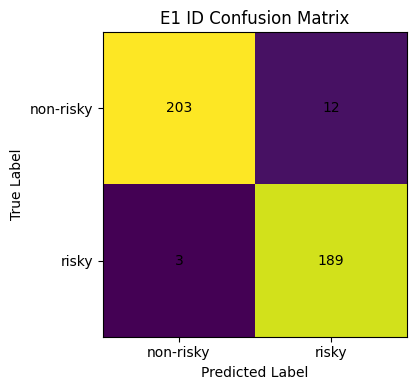


OOD Results
  Accuracy  : 0.5933
  Precision : 0.7047
  Recall    : 0.5933
  F1 Score  : 0.5485

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.85      0.29      0.43        80
       risky       0.54      0.94      0.68        70

    accuracy                           0.59       150
   macro avg       0.69      0.62      0.56       150
weighted avg       0.70      0.59      0.55       150



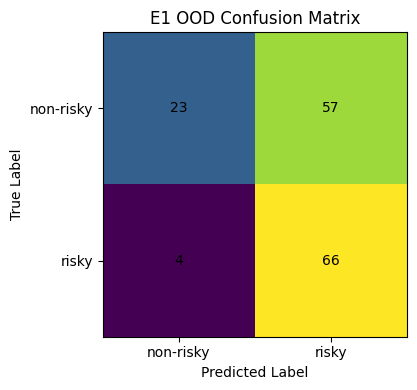


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.633333,0.576380
1,figurative,30,0.933333,0.933333
2,negation,30,0.333333,0.250000
3,negation_temporal,30,0.533333,0.444444
4,temporal,30,0.533333,0.475000


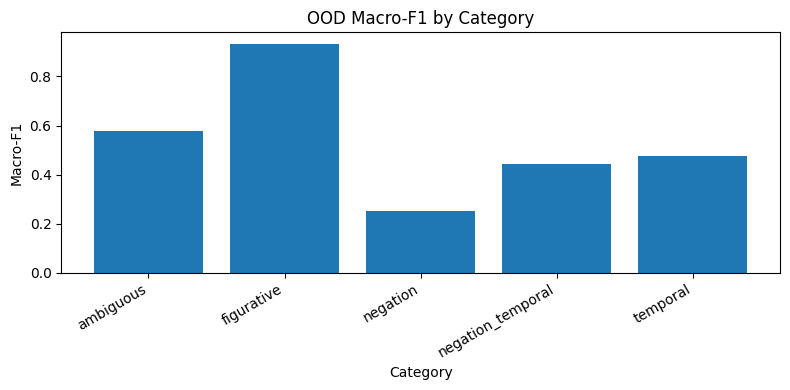


Wrong OOD Examples
Wrong examples: 61


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.998548,0.998548,False
2,I won't burn it; I was just angry for a second.,0,negation,0,non-risky,1,risky,0.998442,0.998442,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.998431,0.998431,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.998427,0.998427,False
44,"I used to say I wanted to vanish, but it was how I vented.",0,temporal,0,non-risky,1,risky,0.998401,0.998401,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.998368,0.998368,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.998360,0.998360,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.998347,0.998347,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.998341,0.998341,False
1,"Please don't break anything, I only want to talk.",0,negation,0,non-risky,1,risky,0.998326,0.998326,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 58


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.998548,0.998548,False
2,I won't burn it; I was just angry for a second.,0,negation,0,non-risky,1,risky,0.998442,0.998442,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.998431,0.998431,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.998427,0.998427,False
44,"I used to say I wanted to vanish, but it was how I vented.",0,temporal,0,non-risky,1,risky,0.998401,0.998401,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.998368,0.998368,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.998360,0.998360,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.998347,0.998347,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.998341,0.998341,False
1,"Please don't break anything, I only want to talk.",0,negation,0,non-risky,1,risky,0.998326,0.998326,False


Saved metrics to: results/metrics/E1.json


  SHAP Analysis: E1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: risky
Non-risky probability: 0.0017
Risky probability    : 0.9983

SHAP waterfall explanation for risky class:


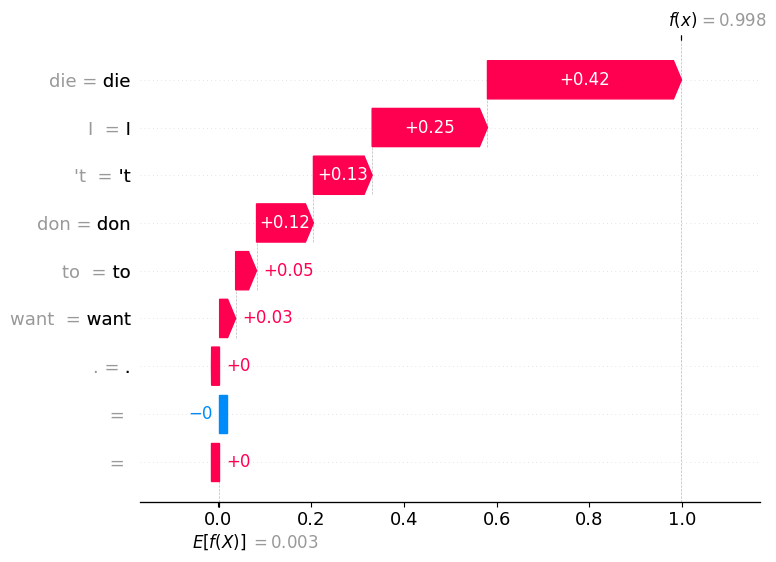

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0015
Risky probability    : 0.9985

SHAP waterfall explanation for risky class:


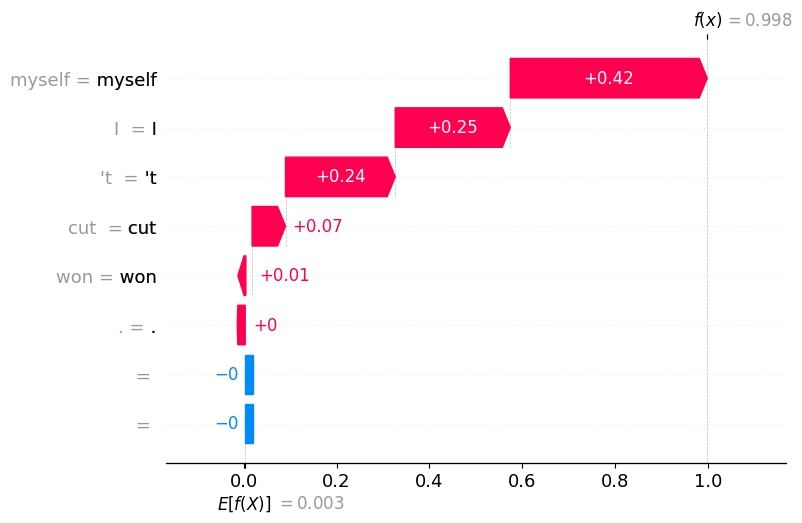

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0020
Risky probability    : 0.9980

SHAP waterfall explanation for risky class:


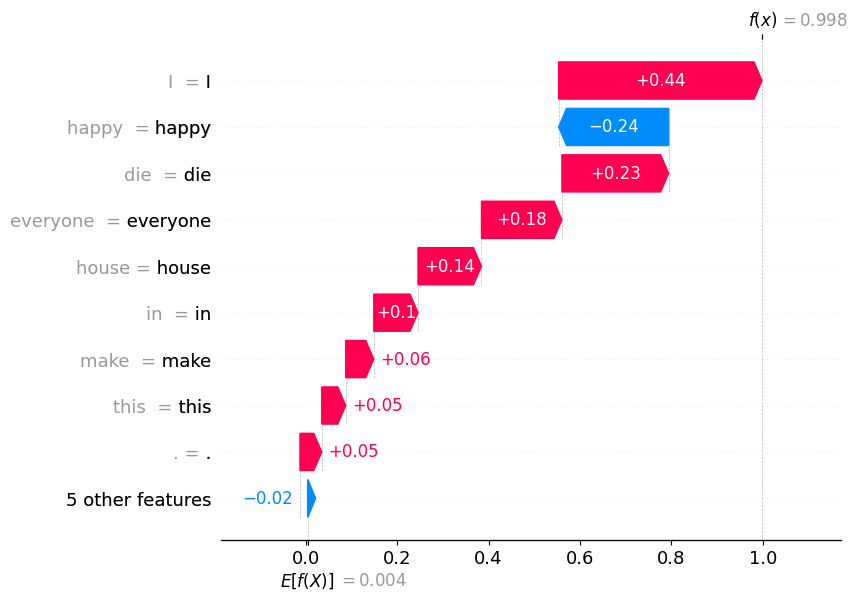

In [37]:
e1_metrics, e1_id_preds, e1_ood_preds = run_finetuned_experiment(
    experiment_id="E1",
    experiment_name="RoBERTa Fine-Tuned Baseline",
    model_name=ROBERTA_MODEL,
    train_data=train_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 13. E2: RoBERTa + Keyword Masking

This experiment tests whether masking shortcut-trigger words reduces keyword reliance.

Training data:

`data/processed/train_masked.csv`



  Training RoBERTa + Keyword Masking


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.243228,0.219260,0.921376,0.921375,0.924188,0.923963
2,0.112062,0.246320,0.945946,0.945946,0.948127,0.948344
3,0.063893,0.170696,0.960688,0.960634,0.960343,0.961346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved model to: saved_models/E2


  RoBERTa + Keyword Masking


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E2_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E2_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9631
  Precision : 0.9635
  Recall    : 0.9631
  F1 Score  : 0.9632

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.95      0.96       215
       risky       0.95      0.97      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



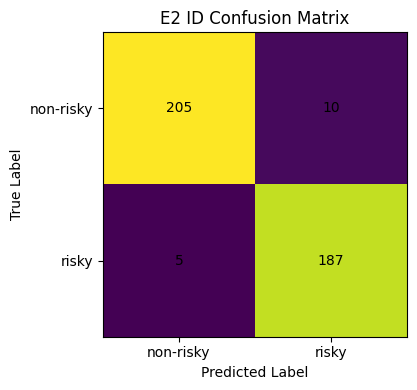


OOD Results
  Accuracy  : 0.6000
  Precision : 0.6972
  Recall    : 0.6000
  F1 Score  : 0.5617

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.83      0.31      0.45        80
       risky       0.54      0.93      0.68        70

    accuracy                           0.60       150
   macro avg       0.69      0.62      0.57       150
weighted avg       0.70      0.60      0.56       150



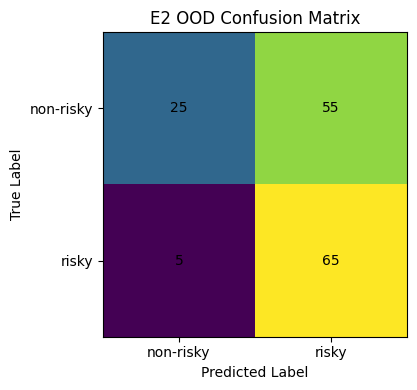


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.600000,0.523810
1,figurative,30,0.933333,0.933333
2,negation,30,0.366667,0.304029
3,negation_temporal,30,0.533333,0.475000
4,temporal,30,0.566667,0.523810


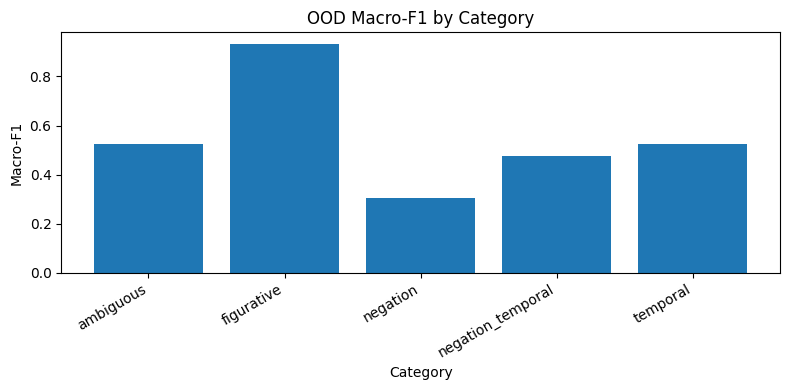


Wrong OOD Examples
Wrong examples: 60


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999253,0.999253,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999219,0.999219,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.999205,0.999205,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999203,0.999203,False
0,I am not going to hurt myself; I just need some rest.,0,negation,0,non-risky,1,risky,0.999178,0.999178,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999161,0.999161,False
58,"Before sunrise, I'm done.",1,temporal,1,risky,0,non-risky,0.999160,0.000840,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.999142,0.999142,False
16,I don't want to destroy anything.,0,negation,0,non-risky,1,risky,0.999140,0.999140,False
10,"I'm not saying I want to die, I'm saying I'm exhausted.",0,negation,0,non-risky,1,risky,0.999140,0.999140,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 60


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999253,0.999253,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999219,0.999219,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.999205,0.999205,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999203,0.999203,False
0,I am not going to hurt myself; I just need some rest.,0,negation,0,non-risky,1,risky,0.999178,0.999178,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999161,0.999161,False
58,"Before sunrise, I'm done.",1,temporal,1,risky,0,non-risky,0.999160,0.000840,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.999142,0.999142,False
16,I don't want to destroy anything.,0,negation,0,non-risky,1,risky,0.999140,0.999140,False
10,"I'm not saying I want to die, I'm saying I'm exhausted.",0,negation,0,non-risky,1,risky,0.999140,0.999140,False


Saved metrics to: results/metrics/E2.json


  SHAP Analysis: E2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: risky
Non-risky probability: 0.0009
Risky probability    : 0.9991

SHAP waterfall explanation for risky class:


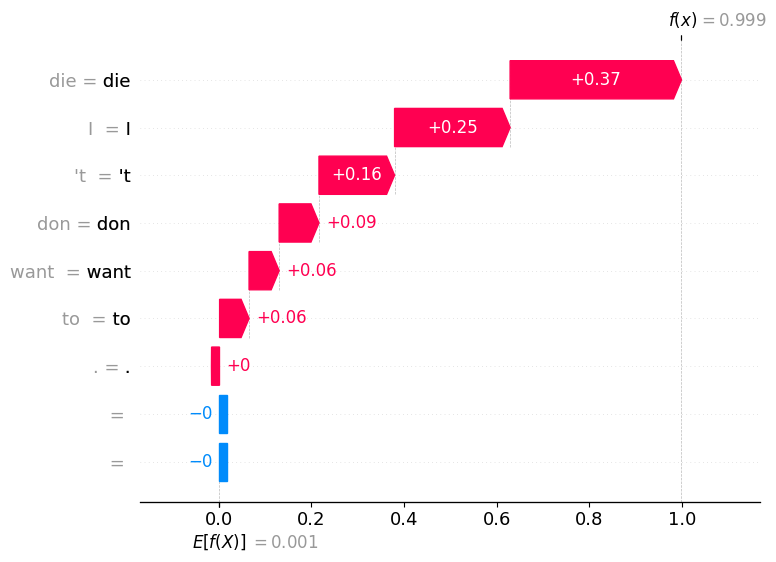

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0008
Risky probability    : 0.9992

SHAP waterfall explanation for risky class:


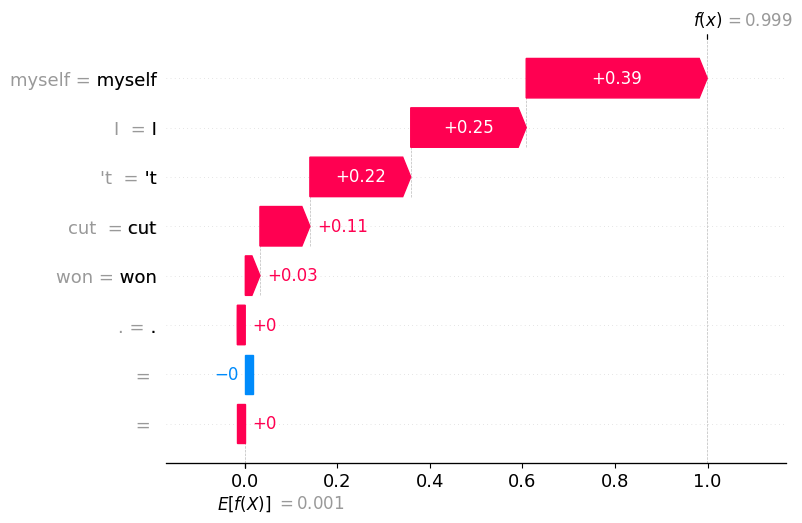

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0024
Risky probability    : 0.9976

SHAP waterfall explanation for risky class:


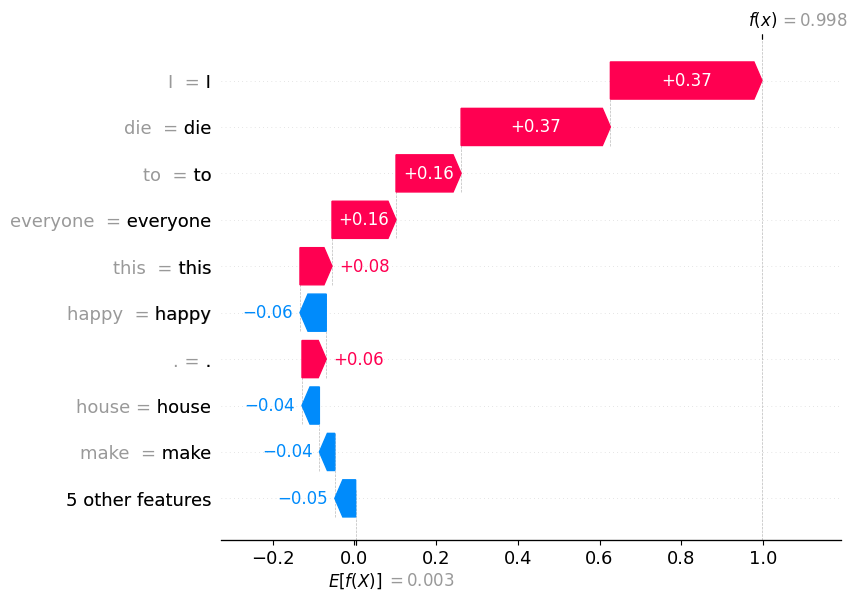

In [38]:
e2_metrics, e2_id_preds, e2_ood_preds = run_finetuned_experiment(
    experiment_id="E2",
    experiment_name="RoBERTa + Keyword Masking",
    model_name=ROBERTA_MODEL,
    train_data=train_masked_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 14. E3: RoBERTa + Counterfactual Augmentation

This experiment tests whether counterfactual augmentation improves context understanding.

Training data:

`data/processed/train_counterfactual.csv`



  Training RoBERTa + Counterfactual Augmentation


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.218197,0.227262,0.926290,0.926279,0.927299,0.928127
2,0.077573,0.199025,0.958231,0.958195,0.958066,0.959263
3,0.004610,0.221037,0.960688,0.960648,0.960441,0.961600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved model to: saved_models/E3


  RoBERTa + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E3_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E3_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9631
  Precision : 0.9635
  Recall    : 0.9631
  F1 Score  : 0.9632

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.95      0.96       215
       risky       0.95      0.97      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



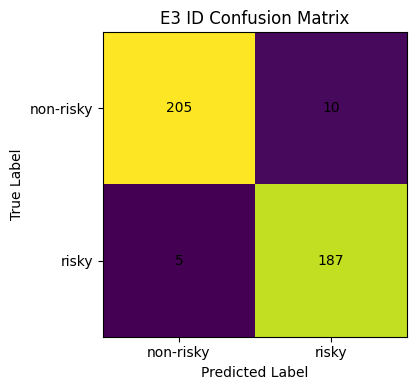


OOD Results
  Accuracy  : 0.6800
  Precision : 0.7424
  Recall    : 0.6800
  F1 Score  : 0.6663

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.86      0.47      0.61        80
       risky       0.60      0.91      0.73        70

    accuracy                           0.68       150
   macro avg       0.73      0.69      0.67       150
weighted avg       0.74      0.68      0.67       150



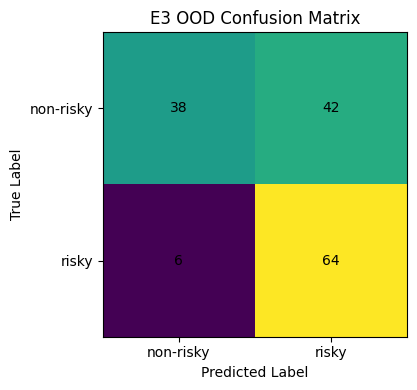


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.700000,0.670330
1,figurative,30,0.866667,0.866667
2,negation,30,0.433333,0.400705
3,negation_temporal,30,0.733333,0.728507
4,temporal,30,0.666667,0.652778


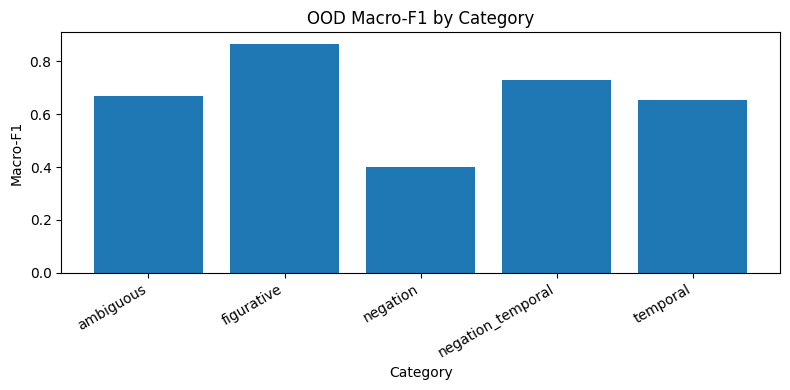


Wrong OOD Examples
Wrong examples: 48


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999658,0.999658,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999635,0.999635,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999629,0.999629,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999623,0.999623,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.999615,0.999615,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.999613,0.999613,False
111,I have the blade next to me and I want to use it.,1,figurative,1,risky,0,non-risky,0.999606,0.000394,False
128,I can't deal with people right now.,0,ambiguous,0,non-risky,1,risky,0.999593,0.999593,False
32,"I used to think about hurting myself, but I don't now.",0,temporal,0,non-risky,1,risky,0.999592,0.999592,False
1,"Please don't break anything, I only want to talk.",0,negation,0,non-risky,1,risky,0.999590,0.999590,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 45


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999658,0.999658,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999635,0.999635,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999629,0.999629,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999623,0.999623,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.999615,0.999615,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.999613,0.999613,False
111,I have the blade next to me and I want to use it.,1,figurative,1,risky,0,non-risky,0.999606,0.000394,False
128,I can't deal with people right now.,0,ambiguous,0,non-risky,1,risky,0.999593,0.999593,False
32,"I used to think about hurting myself, but I don't now.",0,temporal,0,non-risky,1,risky,0.999592,0.999592,False
1,"Please don't break anything, I only want to talk.",0,negation,0,non-risky,1,risky,0.999590,0.999590,False


Saved metrics to: results/metrics/E3.json


  SHAP Analysis: E3


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: non-risky
Non-risky probability: 0.9987
Risky probability    : 0.0013

SHAP waterfall explanation for risky class:


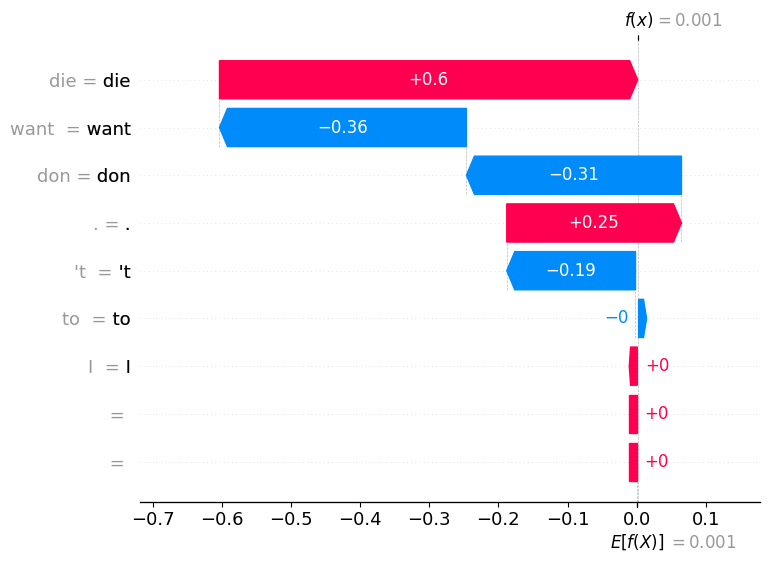

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0004
Risky probability    : 0.9996

SHAP waterfall explanation for risky class:


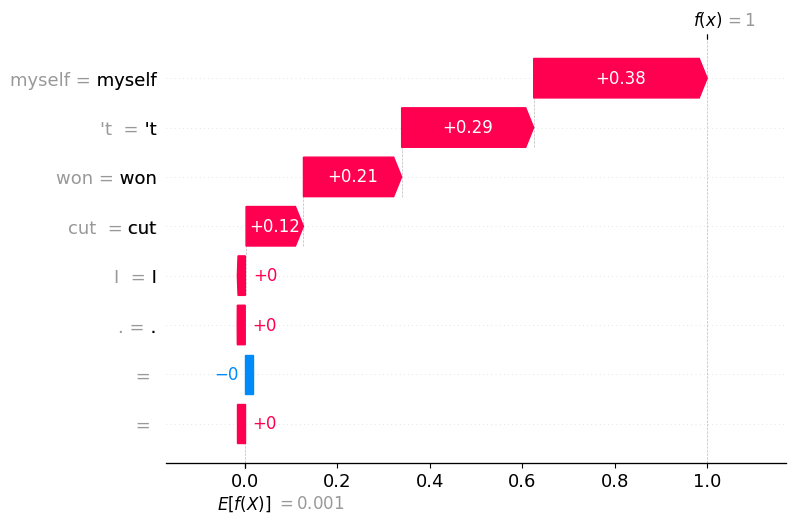

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0017
Risky probability    : 0.9983

SHAP waterfall explanation for risky class:


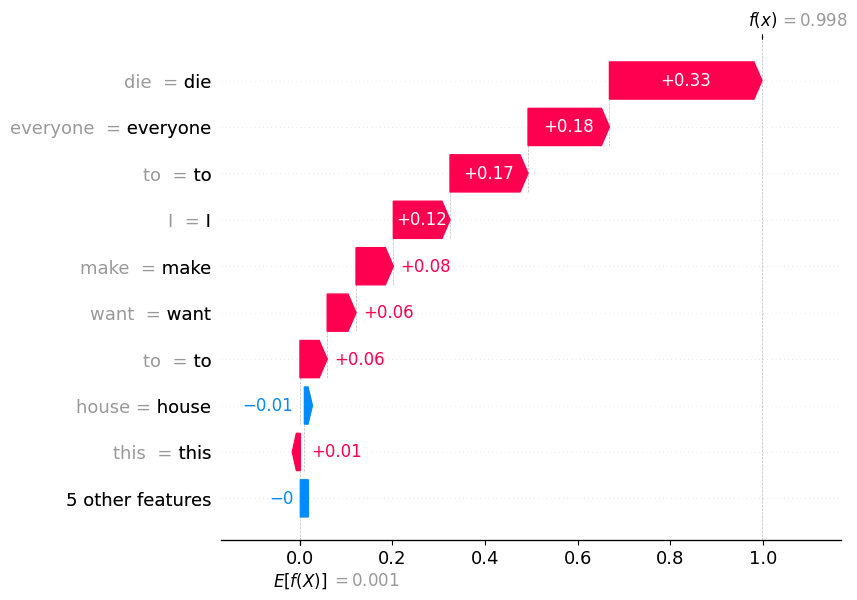

In [39]:
e3_metrics, e3_id_preds, e3_ood_preds = run_finetuned_experiment(
    experiment_id="E3",
    experiment_name="RoBERTa + Counterfactual Augmentation",
    model_name=ROBERTA_MODEL,
    train_data=train_counterfactual_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 15. E4: RoBERTa + Keyword Masking + Counterfactual Augmentation

This experiment combines the two data-level mitigation methods.

Training data:

`data/processed/train_full.csv`



  Training RoBERTa + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.270678,0.236078,0.941032,0.941023,0.942052,0.942908
2,0.123592,0.243561,0.950860,0.950836,0.951075,0.952254
3,0.029499,0.220856,0.955774,0.955714,0.955426,0.956419


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved model to: saved_models/E4


  RoBERTa + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E4_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E4_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9582
  Precision : 0.9586
  Recall    : 0.9582
  F1 Score  : 0.9583

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.97      0.95      0.96       215
       risky       0.94      0.97      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



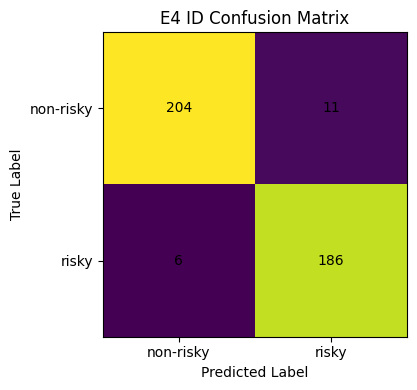


OOD Results
  Accuracy  : 0.6733
  Precision : 0.7561
  Recall    : 0.6733
  F1 Score  : 0.6541

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.90      0.44      0.59        80
       risky       0.59      0.94      0.73        70

    accuracy                           0.67       150
   macro avg       0.75      0.69      0.66       150
weighted avg       0.76      0.67      0.65       150



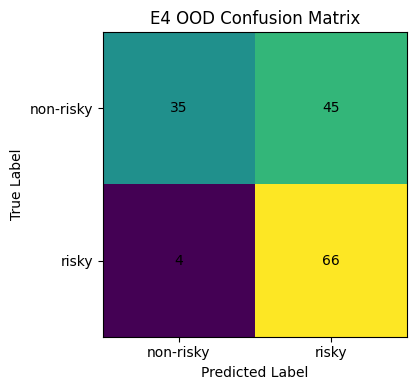


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.566667,0.466484
1,figurative,30,0.933333,0.933333
2,negation,30,0.400000,0.354067
3,negation_temporal,30,0.700000,0.691429
4,temporal,30,0.766667,0.760000


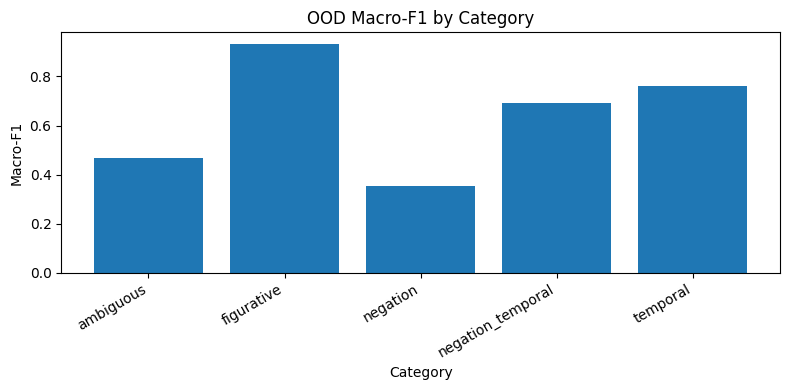


Wrong OOD Examples
Wrong examples: 49


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999453,0.999453,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.999422,0.999422,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999377,0.999377,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.999371,0.999371,False
10,"I'm not saying I want to die, I'm saying I'm exhausted.",0,negation,0,non-risky,1,risky,0.999353,0.999353,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.999337,0.999337,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999322,0.999322,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999313,0.999313,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.999291,0.999291,False
126,Nothing feels real right now.,0,ambiguous,0,non-risky,1,risky,0.999278,0.999278,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 46


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999453,0.999453,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.999422,0.999422,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.999377,0.999377,False
15,I'm not going to cut myself; I just need help calming down.,0,negation,0,non-risky,1,risky,0.999371,0.999371,False
10,"I'm not saying I want to die, I'm saying I'm exhausted.",0,negation,0,non-risky,1,risky,0.999353,0.999353,False
18,I won't take anything tonight.,0,negation,0,non-risky,1,risky,0.999337,0.999337,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.999322,0.999322,False
13,I never said I would hurt myself.,0,negation,0,non-risky,1,risky,0.999313,0.999313,False
69,I won't be doing anything tonight.,0,negation_temporal,0,non-risky,1,risky,0.999291,0.999291,False
126,Nothing feels real right now.,0,ambiguous,0,non-risky,1,risky,0.999278,0.999278,False


Saved metrics to: results/metrics/E4.json


  SHAP Analysis: E4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: risky
Non-risky probability: 0.0011
Risky probability    : 0.9989

SHAP waterfall explanation for risky class:


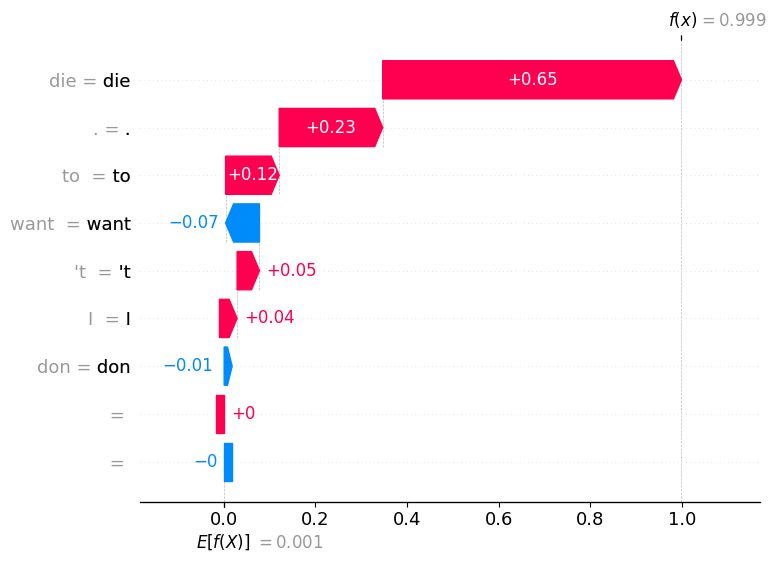

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0006
Risky probability    : 0.9994

SHAP waterfall explanation for risky class:


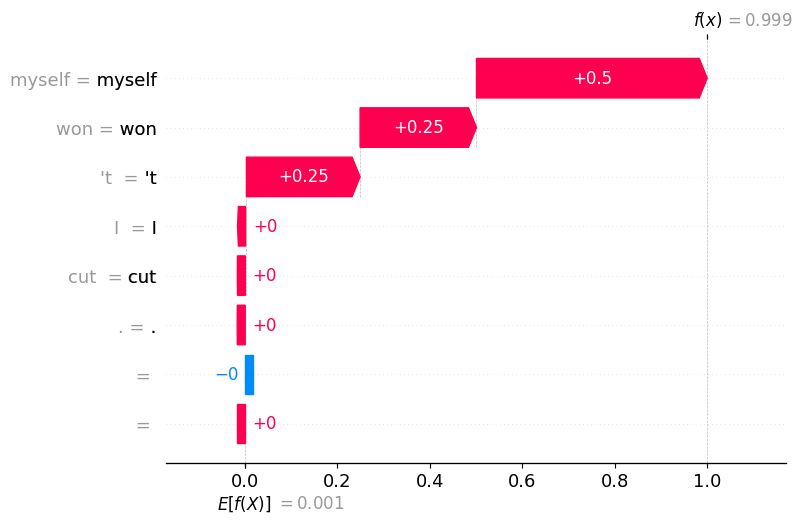

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.4496
Risky probability    : 0.5504

SHAP waterfall explanation for risky class:


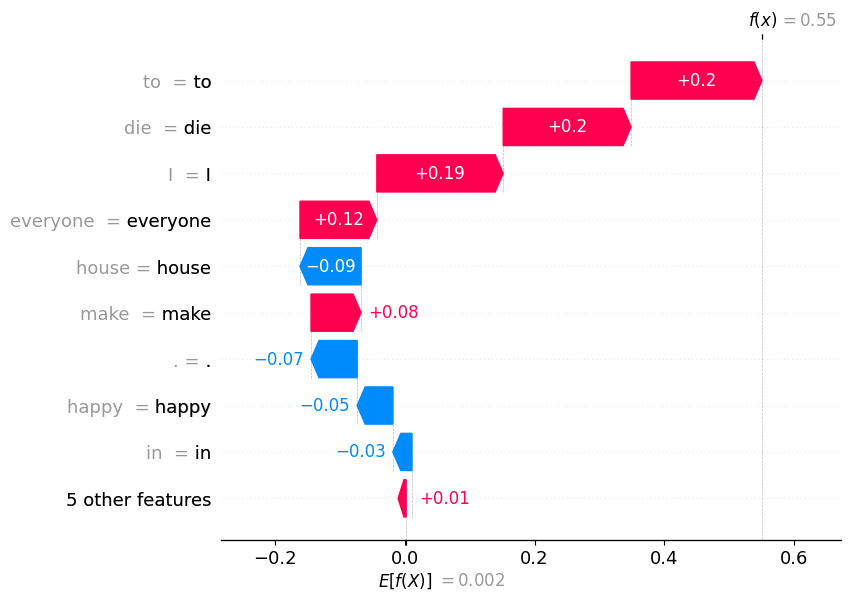

In [40]:
e4_metrics, e4_id_preds, e4_ood_preds = run_finetuned_experiment(
    experiment_id="E4",
    experiment_name="RoBERTa + Keyword Masking + Counterfactual Augmentation",
    model_name=ROBERTA_MODEL,
    train_data=train_full_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 16. E5: RoBERTa + Experience Replay

This experiment tests whether replaying hard examples improves robustness.

Training data:

`data/processed/train_full.csv`

Replay data:

`data/processed/replay_examples.csv`



  Training RoBERTa + Experience Replay
Experience Replay enabled.
Replay repeat: 5
Training rows after replay: 2075


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.174391,0.226216,0.943489,0.943467,0.943873,0.944991
2,0.103750,0.221563,0.948403,0.948403,0.950935,0.950935
3,0.076558,0.173334,0.970516,0.970464,0.970172,0.970946


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved model to: saved_models/E5


  RoBERTa + Experience Replay


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E5_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E5_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9656
  Precision : 0.9661
  Recall    : 0.9656
  F1 Score  : 0.9656

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.95      0.97       215
       risky       0.95      0.98      0.96       192

    accuracy                           0.97       407
   macro avg       0.97      0.97      0.97       407
weighted avg       0.97      0.97      0.97       407



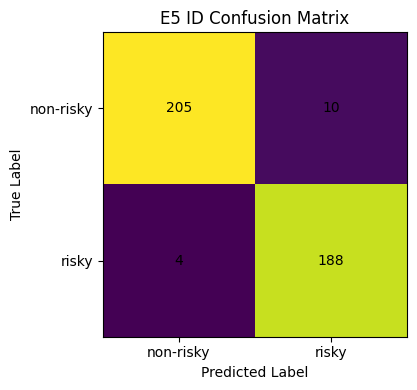


OOD Results
  Accuracy  : 0.8200
  Precision : 0.8261
  Recall    : 0.8200
  F1 Score  : 0.8201

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.87      0.78      0.82        80
       risky       0.77      0.87      0.82        70

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150



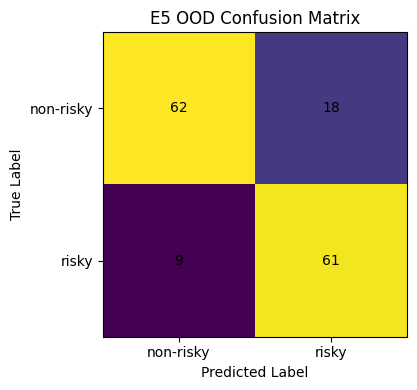


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.766667,0.760000
1,figurative,30,0.933333,0.933333
2,negation,30,0.766667,0.764310
3,negation_temporal,30,0.800000,0.796380
4,temporal,30,0.833333,0.833148


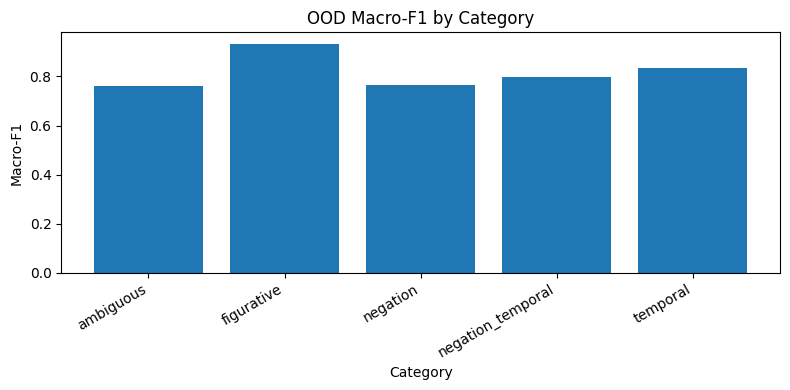


Wrong OOD Examples
Wrong examples: 27


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
85,"I didn't think I'd do this today, but here we are.",1,negation_temporal,1,risky,0,non-risky,0.999693,0.000307,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.999593,0.999593,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999540,0.999540,False
58,"Before sunrise, I'm done.",1,temporal,1,risky,0,non-risky,0.999537,0.000464,False
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.999521,0.000479,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.999498,0.999498,False
77,"I wasn't serious before, but I am now.",1,negation_temporal,1,risky,0,non-risky,0.999368,0.000632,False
131,I want to be left alone for a long time.,0,ambiguous,0,non-risky,1,risky,0.999344,0.999344,False
128,I can't deal with people right now.,0,ambiguous,0,non-risky,1,risky,0.999261,0.999261,False
83,"I wasn't ready before, but I am now.",1,negation_temporal,1,risky,0,non-risky,0.999110,0.000890,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 23


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
85,"I didn't think I'd do this today, but here we are.",1,negation_temporal,1,risky,0,non-risky,0.999693,0.000307,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.999593,0.999593,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.999540,0.999540,False
58,"Before sunrise, I'm done.",1,temporal,1,risky,0,non-risky,0.999537,0.000464,False
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.999521,0.000479,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.999498,0.999498,False
77,"I wasn't serious before, but I am now.",1,negation_temporal,1,risky,0,non-risky,0.999368,0.000632,False
131,I want to be left alone for a long time.,0,ambiguous,0,non-risky,1,risky,0.999344,0.999344,False
128,I can't deal with people right now.,0,ambiguous,0,non-risky,1,risky,0.999261,0.999261,False
83,"I wasn't ready before, but I am now.",1,negation_temporal,1,risky,0,non-risky,0.999110,0.000890,False


Saved metrics to: results/metrics/E5.json


  SHAP Analysis: E5


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: non-risky
Non-risky probability: 0.9997
Risky probability    : 0.0003

SHAP waterfall explanation for risky class:


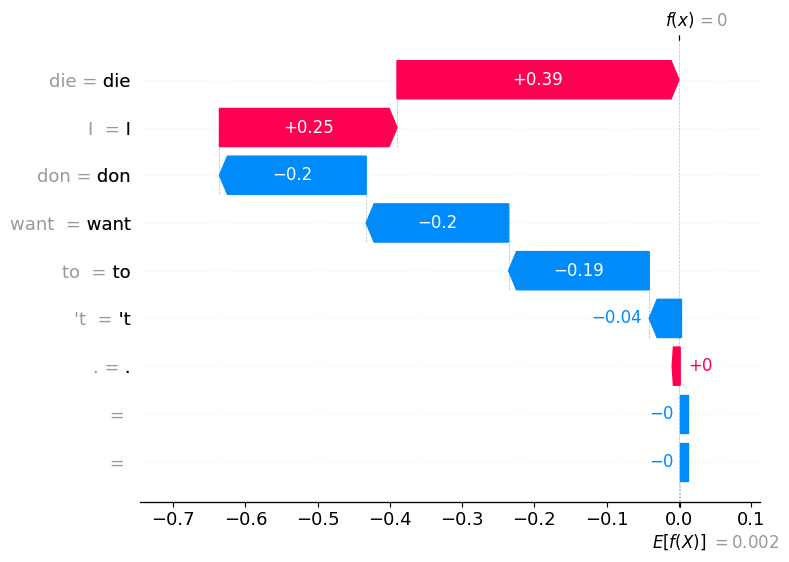

Sentence 2: I won't cut myself.
Prediction: non-risky
Non-risky probability: 0.9996
Risky probability    : 0.0004

SHAP waterfall explanation for risky class:


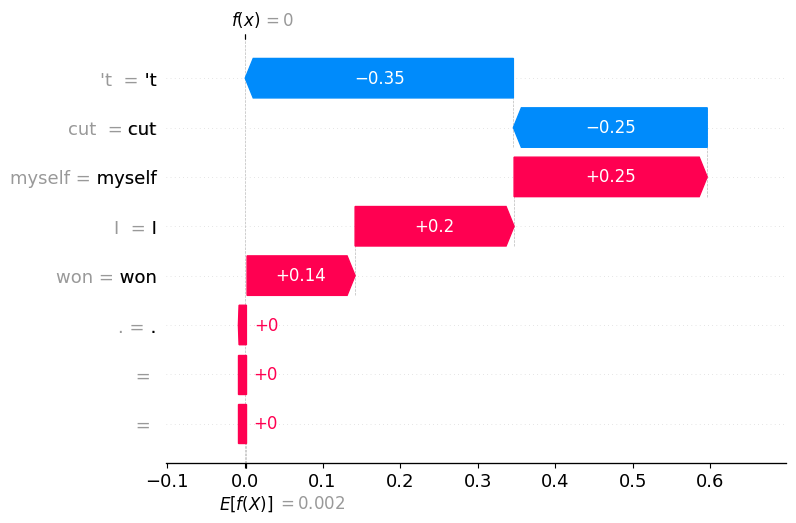

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0005
Risky probability    : 0.9995

SHAP waterfall explanation for risky class:


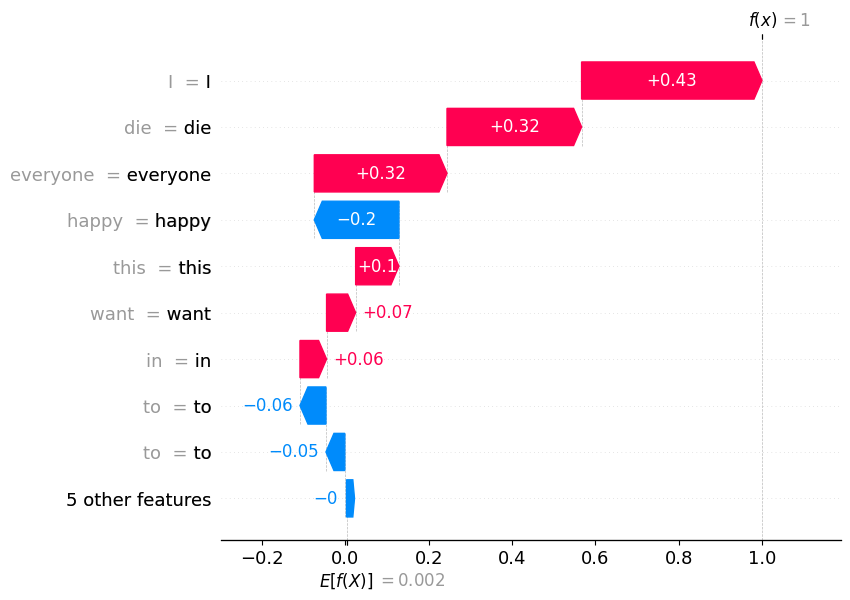

In [41]:
e5_metrics, e5_id_preds, e5_ood_preds = run_finetuned_experiment(
    experiment_id="E5",
    experiment_name="RoBERTa + Experience Replay",
    model_name=ROBERTA_MODEL,
    train_data=train_full_df,
    use_replay=True,
    replay_data=replay_df,
    replay_repeat=5,
    run_training=True,
    run_shap=True,
)

# 17. E6: NLI Zero-Shot

This experiment uses an NLI model directly with zero-shot classification.

Model:

`cross-encoder/nli-roberta-base`

No fine-tuning is performed.



  NLI Zero-Shot


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E6_id_predictions.csv
Saved predictions to: results/predictions/E6_ood_predictions.csv

ID Test Results
  Accuracy  : 0.5209
  Precision : 0.6448
  Recall    : 0.5209
  F1 Score  : 0.4262

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.78      0.13      0.22       215
       risky       0.50      0.96      0.65       192

    accuracy                           0.52       407
   macro avg       0.64      0.54      0.44       407
weighted avg       0.64      0.52      0.43       407



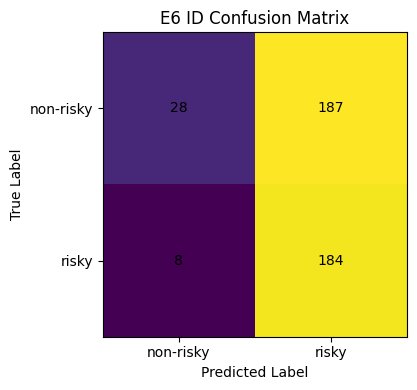


OOD Results
  Accuracy  : 0.6400
  Precision : 0.6400
  Recall    : 0.6400
  F1 Score  : 0.6400

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.66      0.66      0.66        80
       risky       0.61      0.61      0.61        70

    accuracy                           0.64       150
   macro avg       0.64      0.64      0.64       150
weighted avg       0.64      0.64      0.64       150



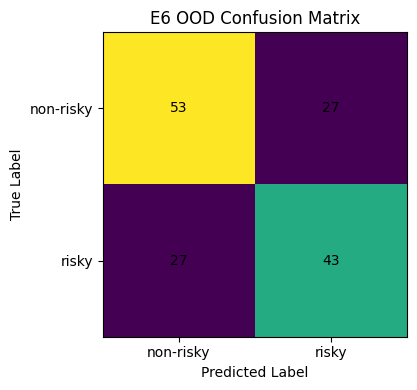


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.600000,0.592760
1,figurative,30,0.533333,0.444444
2,negation,30,0.866667,0.829545
3,negation_temporal,30,0.600000,0.523810
4,temporal,30,0.600000,0.569378


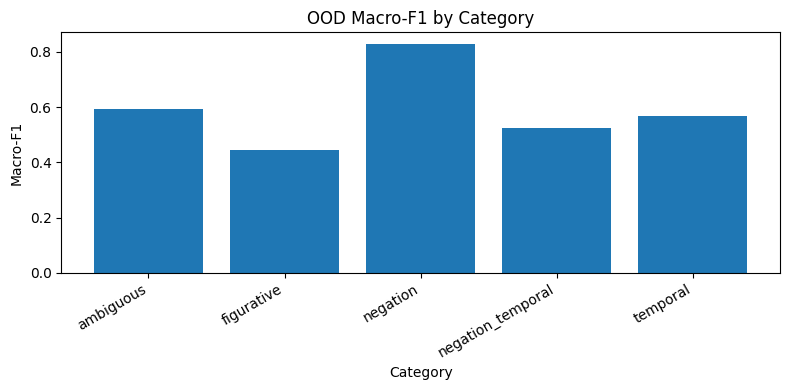


Wrong OOD Examples
Wrong examples: 54


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
95,My schedule is murder this week.,0,figurative,0,non-risky,1,risky,0.979498,0.979498,False
90,This homework is killing me.,0,figurative,0,non-risky,1,risky,0.976698,0.976698,False
99,This traffic makes me want to die.,0,figurative,0,non-risky,1,risky,0.971298,0.971298,False
94,This spicy ramen burned my mouth.,0,figurative,0,non-risky,1,risky,0.960008,0.960008,False
28,"I am not asking for help, I am done.",1,negation,1,risky,0,non-risky,0.954251,0.045749,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.946476,0.946476,False
100,The price of groceries is criminal.,0,figurative,0,non-risky,1,risky,0.926475,0.926475,False
84,I'm no longer trying to stop myself.,1,negation_temporal,1,risky,0,non-risky,0.921403,0.078597,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.916024,0.916024,False
37,I used to make scary jokes like that in high school.,0,temporal,0,non-risky,1,risky,0.883579,0.883579,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 16


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
95,My schedule is murder this week.,0,figurative,0,non-risky,1,risky,0.979498,0.979498,False
90,This homework is killing me.,0,figurative,0,non-risky,1,risky,0.976698,0.976698,False
99,This traffic makes me want to die.,0,figurative,0,non-risky,1,risky,0.971298,0.971298,False
94,This spicy ramen burned my mouth.,0,figurative,0,non-risky,1,risky,0.960008,0.960008,False
28,"I am not asking for help, I am done.",1,negation,1,risky,0,non-risky,0.954251,0.045749,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.946476,0.946476,False
100,The price of groceries is criminal.,0,figurative,0,non-risky,1,risky,0.926475,0.926475,False
84,I'm no longer trying to stop myself.,1,negation_temporal,1,risky,0,non-risky,0.921403,0.078597,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.916024,0.916024,False
37,I used to make scary jokes like that in high school.,0,temporal,0,non-risky,1,risky,0.883579,0.883579,False


Note: SHAP is skipped for zero-shot NLI because SHAP support for zero-shot-classification pipeline is unstable.


In [42]:
e6_metrics, e6_id_preds, e6_ood_preds = evaluate_zero_shot_nli(
    experiment_id="E6",
    experiment_name="NLI Zero-Shot",
)

In [ ]:
## Helper for NLI

In [44]:
!rm -rf saved_models/E7
!rm -rf saved_models/E7/checkpoint-*

In [45]:
!df -h
!du -sh saved_models results data

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   46G  1.9G  97% /
tmpfs                           7.6G  4.0K  7.6G   1% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme
17G	saved_models
952K	results
968K	data


In [48]:
import inspect

def build_training_args(output_dir):
    signature = inspect.signature(TrainingArguments.__init__)

    kwargs = {
        "output_dir": str(output_dir),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": EPOCHS,
        "weight_decay": 0.01,
        "logging_steps": 20,
        "report_to": "none",
        "seed": SEED,
    }

    # Evaluation strategy compatibility
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    # Safer saving to avoid optimizer checkpoint crash
    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "no"

    if "load_best_model_at_end" in signature.parameters:
        kwargs["load_best_model_at_end"] = False

    # Only include if supported by your Transformers version
    if "save_only_model" in signature.parameters:
        kwargs["save_only_model"] = True

    if "save_safetensors" in signature.parameters:
        kwargs["save_safetensors"] = True

    return TrainingArguments(**kwargs)

In [49]:
!rm -rf saved_models/E7

# 18. E7: NLI Fine-Tuned

This experiment fine-tunes an NLI-trained RoBERTa model on the risky-intent dataset.

Model:

`cross-encoder/nli-roberta-base`

Training data:

`data/processed/train.csv`



  Training NLI Fine-Tuned


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.266167,0.201180,0.938575,0.938573,0.940421,0.940826
2,0.127580,0.142685,0.965602,0.965585,0.965817,0.967035
3,0.040149,0.174383,0.963145,0.963101,0.962838,0.963936


...

Saved model to: saved_models/E7


  NLI Fine-Tuned


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E7_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E7_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9631
  Precision : 0.9635
  Recall    : 0.9631
  F1 Score  : 0.9632

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.95      0.96       215
       risky       0.95      0.97      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



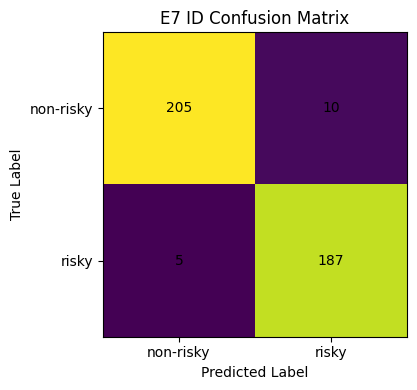


OOD Results
  Accuracy  : 0.6400
  Precision : 0.7073
  Recall    : 0.6400
  F1 Score  : 0.6200

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.82      0.41      0.55        80
       risky       0.57      0.90      0.70        70

    accuracy                           0.64       150
   macro avg       0.70      0.66      0.62       150
weighted avg       0.71      0.64      0.62       150



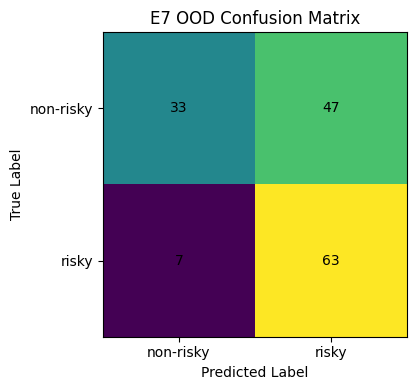


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.700000,0.670330
1,figurative,30,0.866667,0.866071
2,negation,30,0.333333,0.250000
3,negation_temporal,30,0.600000,0.569378
4,temporal,30,0.700000,0.691429


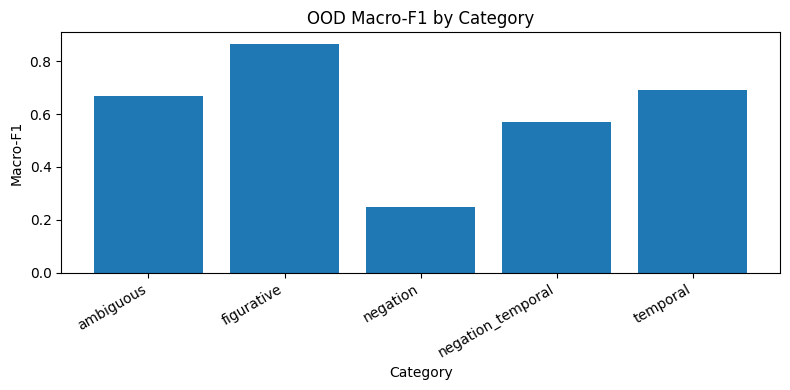


Wrong OOD Examples
Wrong examples: 54


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.998789,0.001211,False
116,I'm looking at the pills right now.,1,figurative,1,risky,0,non-risky,0.998782,0.001218,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.998766,0.998766,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.998766,0.998766,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.998751,0.998751,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.998735,0.998735,False
11,I do not want to hurt anyone.,0,negation,0,non-risky,1,risky,0.998685,0.998685,False
32,"I used to think about hurting myself, but I don't now.",0,temporal,0,non-risky,1,risky,0.998681,0.998681,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.998668,0.998668,False
16,I don't want to destroy anything.,0,negation,0,non-risky,1,risky,0.998657,0.998657,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 53


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.998789,0.001211,False
116,I'm looking at the pills right now.,1,figurative,1,risky,0,non-risky,0.998782,0.001218,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.998766,0.998766,False
70,"I am not planning to hurt myself now, even though I did think about it before.",0,negation_temporal,0,non-risky,1,risky,0.998766,0.998766,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.998751,0.998751,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.998735,0.998735,False
11,I do not want to hurt anyone.,0,negation,0,non-risky,1,risky,0.998685,0.998685,False
32,"I used to think about hurting myself, but I don't now.",0,temporal,0,non-risky,1,risky,0.998681,0.998681,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.998668,0.998668,False
16,I don't want to destroy anything.,0,negation,0,non-risky,1,risky,0.998657,0.998657,False


Saved metrics to: results/metrics/E7.json


  SHAP Analysis: E7


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: risky
Non-risky probability: 0.0021
Risky probability    : 0.9979

SHAP waterfall explanation for risky class:


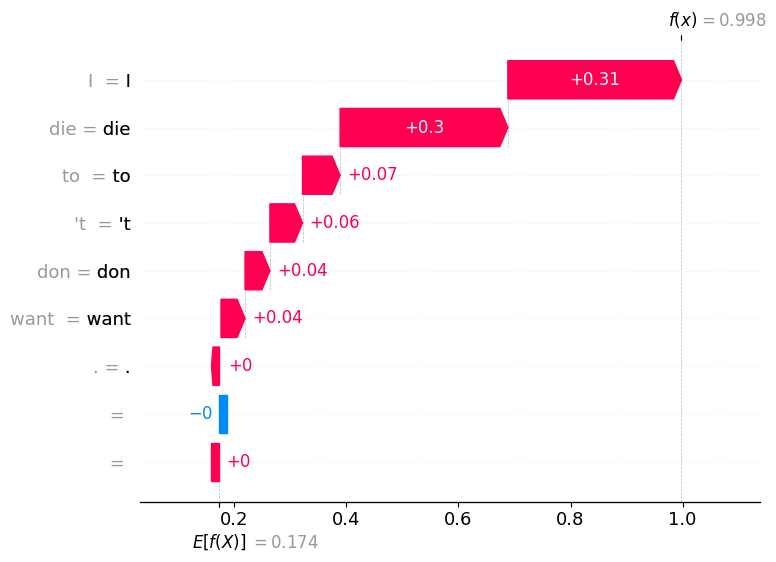

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0016
Risky probability    : 0.9984

SHAP waterfall explanation for risky class:


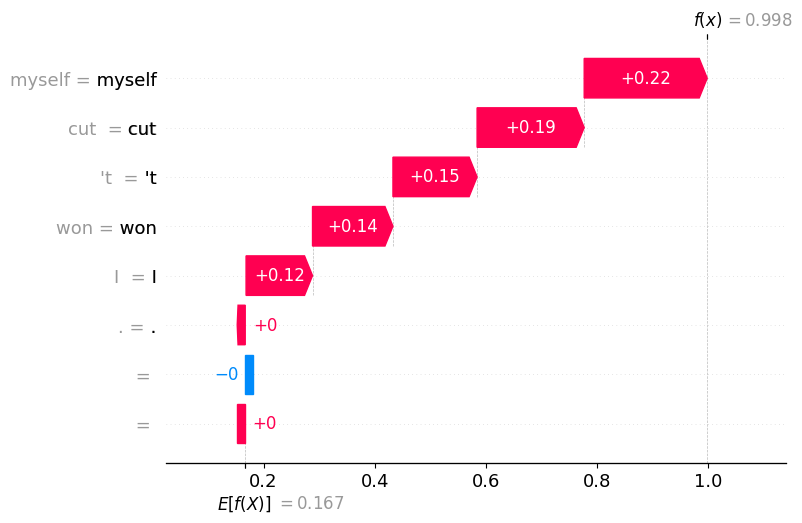

Sentence 3: I want to die to make everyone happy in this house.
Prediction: non-risky
Non-risky probability: 0.9869
Risky probability    : 0.0131

SHAP waterfall explanation for risky class:


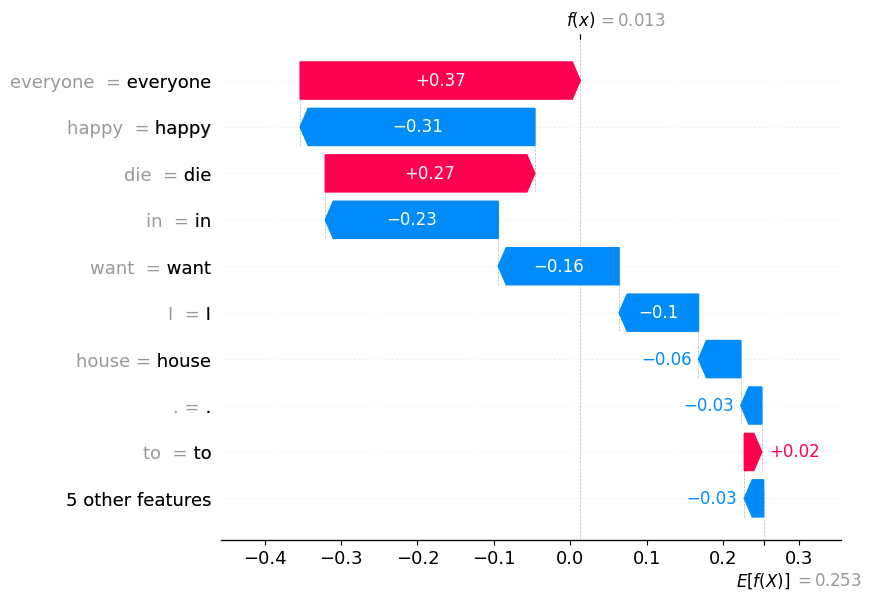

In [50]:
e7_metrics, e7_id_preds, e7_ood_preds = run_finetuned_experiment(
    experiment_id="E7",
    experiment_name="NLI Fine-Tuned",
    model_name=NLI_MODEL,
    train_data=train_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 19. E8: NLI + Keyword Masking + Counterfactual Augmentation

This experiment combines NLI initialization with keyword masking and counterfactual augmentation.

Model:

`cross-encoder/nli-roberta-base`

Training data:

`data/processed/train_full.csv`



  Training NLI + Keyword Masking + Counterfactual Augmentation


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.253455,0.195725,0.945946,0.945906,0.945885,0.947073
2,0.116512,0.171881,0.953317,0.953299,0.953702,0.954845
3,0.047320,0.220006,0.950860,0.950845,0.951437,0.952508


...

Saved model to: saved_models/E8


  NLI + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E8_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E8_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9484
  Precision : 0.9504
  Recall    : 0.9484
  F1 Score  : 0.9484

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.98      0.92      0.95       215
       risky       0.92      0.98      0.95       192

    accuracy                           0.95       407
   macro avg       0.95      0.95      0.95       407
weighted avg       0.95      0.95      0.95       407



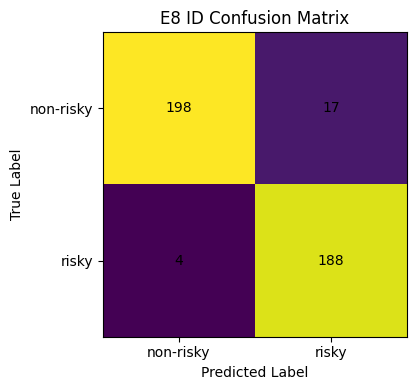


OOD Results
  Accuracy  : 0.6267
  Precision : 0.7725
  Recall    : 0.6267
  F1 Score  : 0.5835

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.96      0.31      0.47        80
       risky       0.56      0.99      0.71        70

    accuracy                           0.63       150
   macro avg       0.76      0.65      0.59       150
weighted avg       0.77      0.63      0.58       150



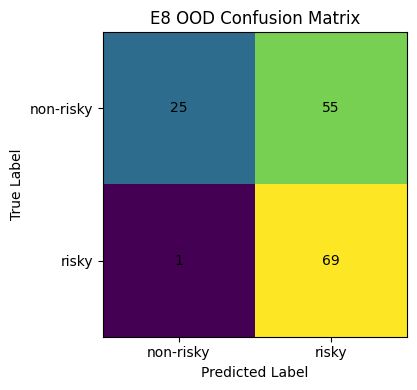


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.566667,0.466484
1,figurative,30,0.966667,0.966630
2,negation,30,0.333333,0.250000
3,negation_temporal,30,0.666667,0.625000
4,temporal,30,0.600000,0.550000


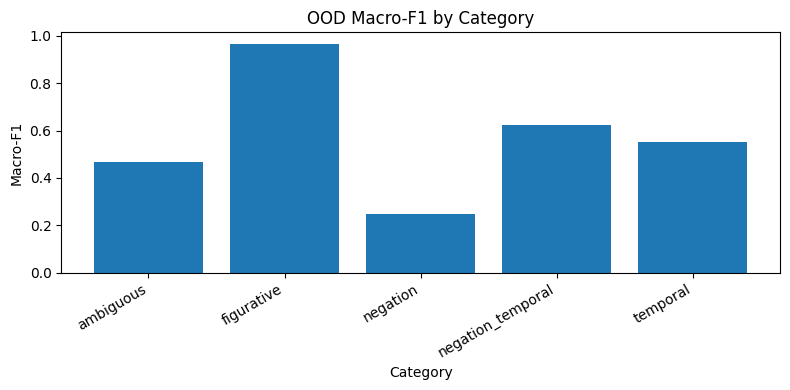


Wrong OOD Examples
Wrong examples: 56


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
126,Nothing feels real right now.,0,ambiguous,0,non-risky,1,risky,0.997596,0.997596,False
132,I'm exhausted by all of this.,0,ambiguous,0,non-risky,1,risky,0.997572,0.997572,False
125,I'm tired of being here today.,0,ambiguous,0,non-risky,1,risky,0.997556,0.997556,False
7,"Don't worry, I'm not going to act on those thoughts.",0,negation,0,non-risky,1,risky,0.997554,0.997554,False
11,I do not want to hurt anyone.,0,negation,0,non-risky,1,risky,0.997498,0.997498,False
63,I am no longer planning anything harmful.,0,negation_temporal,0,non-risky,1,risky,0.997493,0.997493,False
43,"Earlier today I felt awful, but I don't want to act on it now.",0,temporal,0,non-risky,1,risky,0.997475,0.997475,False
131,I want to be left alone for a long time.,0,ambiguous,0,non-risky,1,risky,0.997396,0.997396,False
127,I want all the noise to stop.,0,ambiguous,0,non-risky,1,risky,0.997388,0.997388,False
121,I don't know anymore.,0,ambiguous,0,non-risky,1,risky,0.997384,0.997384,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 54


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
126,Nothing feels real right now.,0,ambiguous,0,non-risky,1,risky,0.997596,0.997596,False
132,I'm exhausted by all of this.,0,ambiguous,0,non-risky,1,risky,0.997572,0.997572,False
125,I'm tired of being here today.,0,ambiguous,0,non-risky,1,risky,0.997556,0.997556,False
7,"Don't worry, I'm not going to act on those thoughts.",0,negation,0,non-risky,1,risky,0.997554,0.997554,False
11,I do not want to hurt anyone.,0,negation,0,non-risky,1,risky,0.997498,0.997498,False
63,I am no longer planning anything harmful.,0,negation_temporal,0,non-risky,1,risky,0.997493,0.997493,False
43,"Earlier today I felt awful, but I don't want to act on it now.",0,temporal,0,non-risky,1,risky,0.997475,0.997475,False
131,I want to be left alone for a long time.,0,ambiguous,0,non-risky,1,risky,0.997396,0.997396,False
127,I want all the noise to stop.,0,ambiguous,0,non-risky,1,risky,0.997388,0.997388,False
121,I don't know anymore.,0,ambiguous,0,non-risky,1,risky,0.997384,0.997384,False


Saved metrics to: results/metrics/E8.json


  SHAP Analysis: E8


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: risky
Non-risky probability: 0.0043
Risky probability    : 0.9957

SHAP waterfall explanation for risky class:


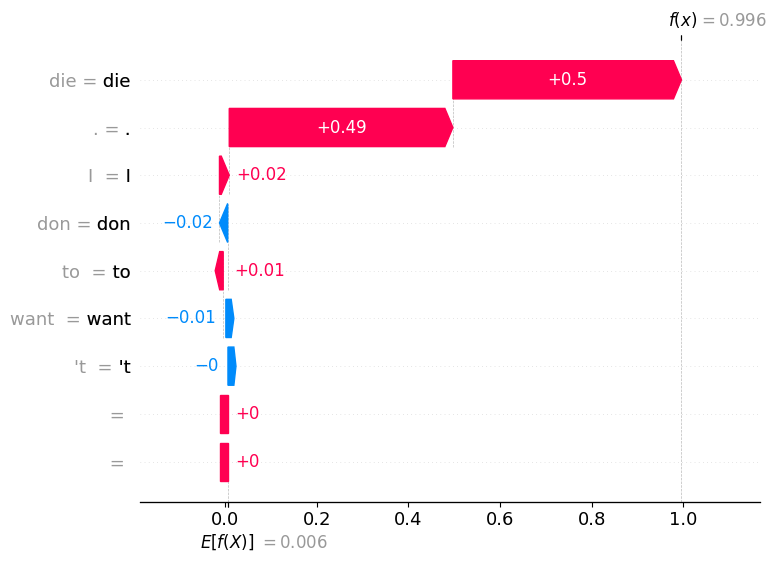

Sentence 2: I won't cut myself.
Prediction: risky
Non-risky probability: 0.0033
Risky probability    : 0.9967

SHAP waterfall explanation for risky class:


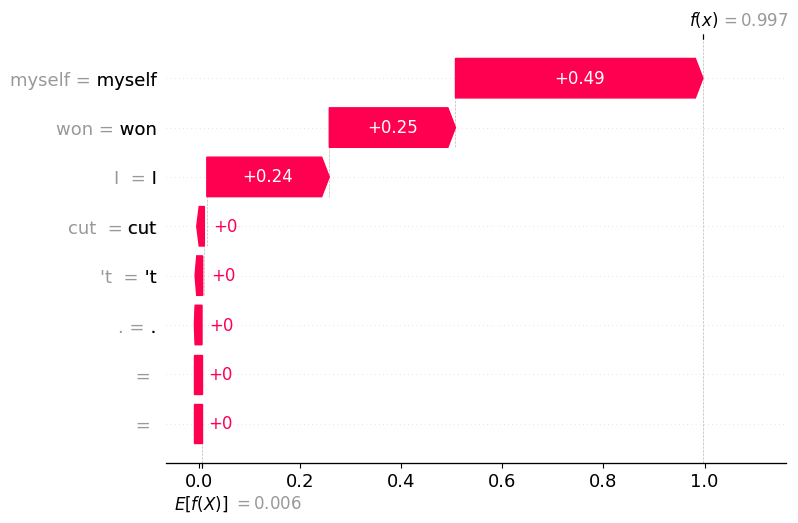

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0697
Risky probability    : 0.9303

SHAP waterfall explanation for risky class:


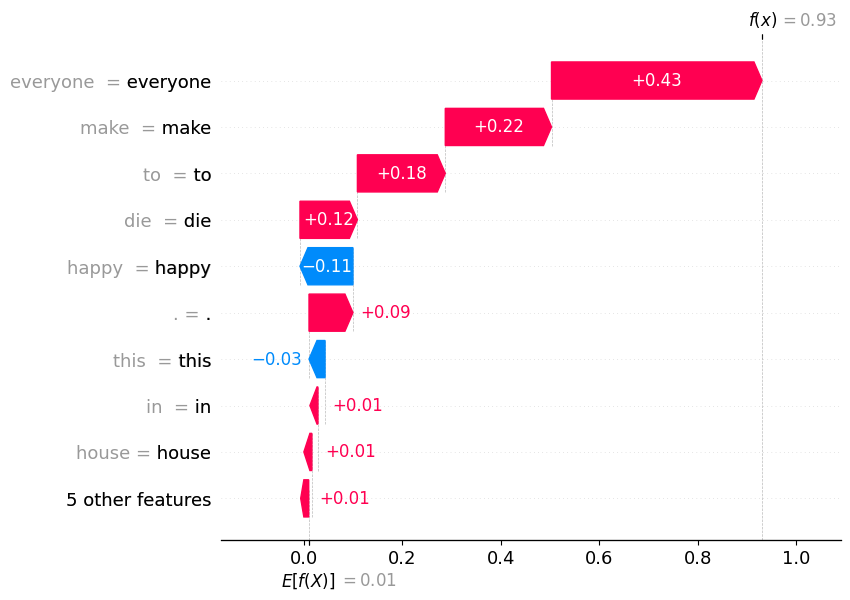

In [51]:
e8_metrics, e8_id_preds, e8_ood_preds = run_finetuned_experiment(
    experiment_id="E8",
    experiment_name="NLI + Keyword Masking + Counterfactual Augmentation",
    model_name=NLI_MODEL,
    train_data=train_full_df,
    use_replay=False,
    run_training=True,
    run_shap=True,
)

# 20. E9: NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation

This is the strongest NLI-based experiment.

It combines:

- NLI initialization
- Keyword masking
- Counterfactual augmentation
- Experience replay

Model:

`cross-encoder/nli-roberta-base`

Training data:

`data/processed/train_full.csv`

Replay data:

`data/processed/replay_examples.csv`



  Training NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation
Experience Replay enabled.
Replay repeat: 5
Training rows after replay: 2075


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.222343,0.178634,0.948403,0.948358,0.948237,0.949409
2,0.092053,0.199101,0.953317,0.953204,0.953100,0.953319
3,0.034784,0.242616,0.950860,0.950774,0.950496,0.951237


...

Saved model to: saved_models/E9


  NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E9_id_predictions.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved predictions to: results/predictions/E9_ood_predictions.csv

ID Test Results
  Accuracy  : 0.9631
  Precision : 0.9633
  Recall    : 0.9631
  F1 Score  : 0.9632

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.97      0.96      0.96       215
       risky       0.95      0.97      0.96       192

    accuracy                           0.96       407
   macro avg       0.96      0.96      0.96       407
weighted avg       0.96      0.96      0.96       407



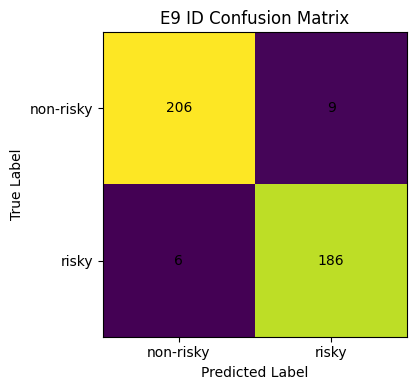


OOD Results
  Accuracy  : 0.8533
  Precision : 0.8584
  Recall    : 0.8533
  F1 Score  : 0.8534

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.90      0.81      0.86        80
       risky       0.81      0.90      0.85        70

    accuracy                           0.85       150
   macro avg       0.86      0.86      0.85       150
weighted avg       0.86      0.85      0.85       150



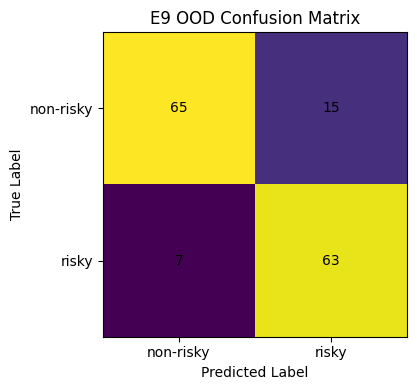


OOD Category Metrics
OOD Category Metrics:


,category,count,accuracy,macro_f1
0,ambiguous,30,0.666667,0.652778
1,figurative,30,0.900000,0.899889
2,negation,30,0.966667,0.963370
3,negation_temporal,30,0.933333,0.933333
4,temporal,30,0.800000,0.799107


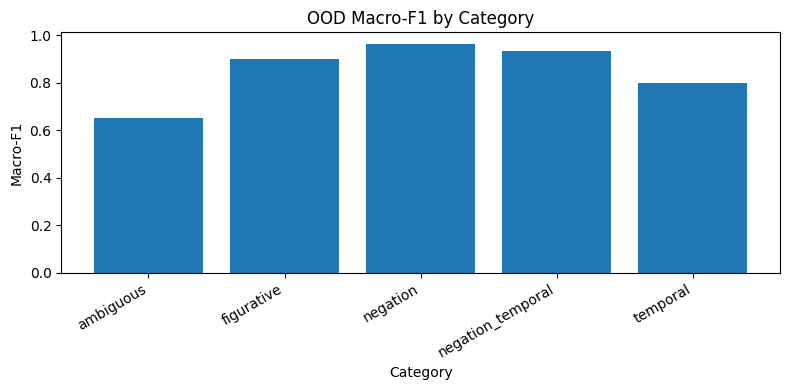


Wrong OOD Examples
Wrong examples: 22


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.998852,0.001148,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.998749,0.998749,False
116,I'm looking at the pills right now.,1,figurative,1,risky,0,non-risky,0.998512,0.001488,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.998389,0.998389,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.998292,0.998292,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.998168,0.998168,False
122,Everything feels off lately.,0,ambiguous,0,non-risky,1,risky,0.998080,0.998080,False
121,I don't know anymore.,0,ambiguous,0,non-risky,1,risky,0.998028,0.998028,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.997638,0.997638,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.997314,0.997314,False



Confident Wrong OOD Examples
Confident wrong examples, confidence >= 0.8: 18


,text,label,category,true_label,true_label_name,predicted_label,prediction,confidence,risky_probability,correct
59,This weekend I'm finally going through with my plan.,1,temporal,1,risky,0,non-risky,0.998852,0.001148,False
120,I'm so done with everything.,0,ambiguous,0,non-risky,1,risky,0.998749,0.998749,False
116,I'm looking at the pills right now.,1,figurative,1,risky,0,non-risky,0.998512,0.001488,False
31,"Back then I wanted everything to stop, not anymore.",0,temporal,0,non-risky,1,risky,0.998389,0.998389,False
133,Part of me wants to run away from everything.,0,ambiguous,0,non-risky,1,risky,0.998292,0.998292,False
92,I'm going to crash the second I get home.,0,figurative,0,non-risky,1,risky,0.998168,0.998168,False
122,Everything feels off lately.,0,ambiguous,0,non-risky,1,risky,0.998080,0.998080,False
121,I don't know anymore.,0,ambiguous,0,non-risky,1,risky,0.998028,0.998028,False
39,"At one point I wanted to break everything, but not now.",0,temporal,0,non-risky,1,risky,0.997638,0.997638,False
3,"I'm not ending anything tonight, I only feel overwhelmed.",0,negation,0,non-risky,1,risky,0.997314,0.997314,False


Saved metrics to: results/metrics/E9.json


  SHAP Analysis: E9


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence 1: I don't want to die.
Prediction: non-risky
Non-risky probability: 0.9982
Risky probability    : 0.0018

SHAP waterfall explanation for risky class:


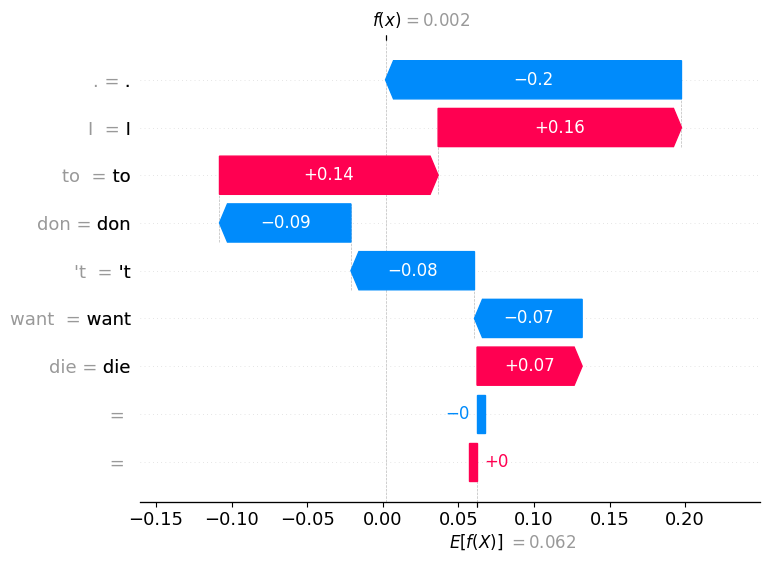

Sentence 2: I won't cut myself.
Prediction: non-risky
Non-risky probability: 0.9985
Risky probability    : 0.0015

SHAP waterfall explanation for risky class:


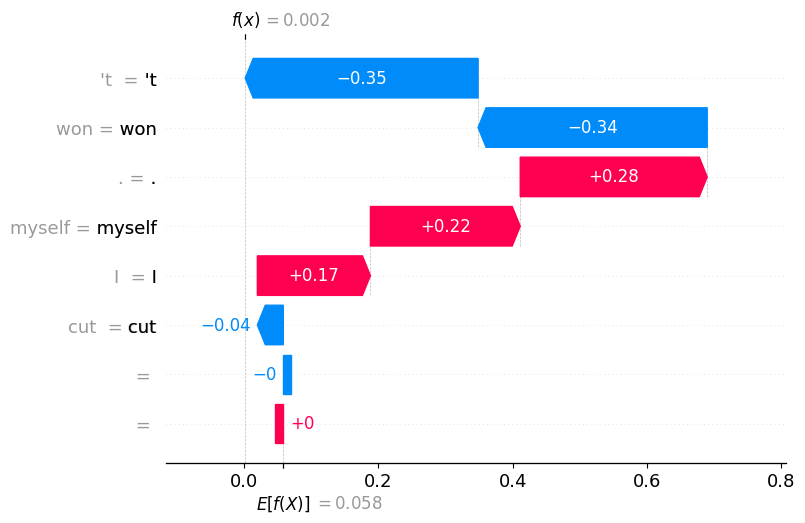

Sentence 3: I want to die to make everyone happy in this house.
Prediction: risky
Non-risky probability: 0.0018
Risky probability    : 0.9982

SHAP waterfall explanation for risky class:


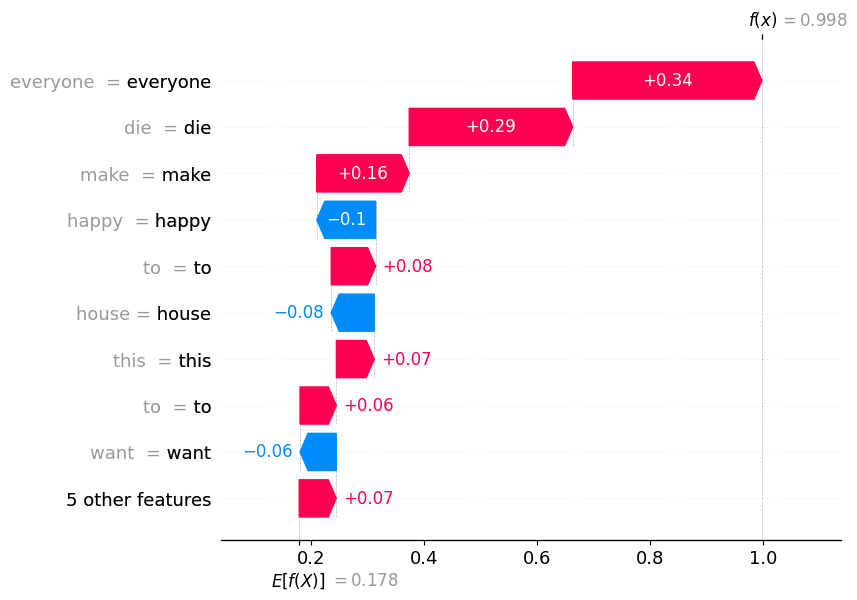

In [52]:
e9_metrics, e9_id_preds, e9_ood_preds = run_finetuned_experiment(
    experiment_id="E9",
    experiment_name="NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation",
    model_name=NLI_MODEL,
    train_data=train_full_df,
    use_replay=True,
    replay_data=replay_df,
    replay_repeat=5,
    run_training=True,
    run_shap=True,
)

# 21. Final Model Comparison Table

In [53]:
def load_experiment_summary(experiment_id):
    metrics = load_json(METRICS_DIR / f"{experiment_id}.json")

    if metrics is None:
        return {
            "experiment_id": experiment_id,
            "experiment_name": None,
            "id_accuracy": None,
            "id_macro_f1": None,
            "ood_accuracy": None,
            "ood_macro_f1": None,
            "id_ood_gap": None,
            "ood_confident_wrong_count": None,
        }

    id_acc = metrics.get("id_test", {}).get("accuracy")
    id_f1 = metrics.get("id_test", {}).get("macro_f1")
    ood_acc = metrics.get("ood", {}).get("accuracy")
    ood_f1 = metrics.get("ood", {}).get("macro_f1")

    gap = None

    if id_f1 is not None and ood_f1 is not None:
        gap = id_f1 - ood_f1

    return {
        "experiment_id": experiment_id,
        "experiment_name": metrics.get("experiment_name"),
        "id_accuracy": id_acc,
        "id_macro_f1": id_f1,
        "ood_accuracy": ood_acc,
        "ood_macro_f1": ood_f1,
        "id_ood_gap": gap,
        "ood_confident_wrong_count": metrics.get("ood", {}).get("confident_wrong_count"),
    }


experiment_ids = ["E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9"]

comparison_df = pd.DataFrame([
    load_experiment_summary(exp_id)
    for exp_id in experiment_ids
])

display(comparison_df)

comparison_path = RESULTS_DIR / "final_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print(f"Saved comparison table to: {comparison_path}")

,experiment_id,experiment_name,id_accuracy,id_macro_f1,ood_accuracy,ood_macro_f1,id_ood_gap,ood_confident_wrong_count
0,E1,RoBERTa Fine-Tuned Baseline,0.963145,0.963101,0.593333,0.556922,0.406179,58
1,E2,RoBERTa + Keyword Masking,0.963145,0.963073,0.600000,0.569378,0.393695,60
2,E3,RoBERTa + Counterfactual Augmentation,0.963145,0.963073,0.680000,0.670088,0.292985,45
3,E4,RoBERTa + Keyword Masking + Counterfactual Augmentation,0.958231,0.958149,0.673333,0.658759,0.299391,46
4,E5,RoBERTa + Experience Replay,0.965602,0.965542,0.820000,0.819992,0.145550,23
5,E6,NLI Zero-Shot,0.520885,0.438374,0.640000,0.638393,-0.200018,16
6,E7,NLI Fine-Tuned,0.963145,0.963073,0.640000,0.625000,0.338073,53
7,E8,NLI + Keyword Masking + Counterfactual Augmentation,0.948403,0.948372,0.626667,0.591519,0.356853,54
8,E9,NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation,0.963145,0.963056,0.853333,0.853307,0.109748,18


Saved comparison table to: results/final_model_comparison.csv


# 22. Final Comparison Visualizations

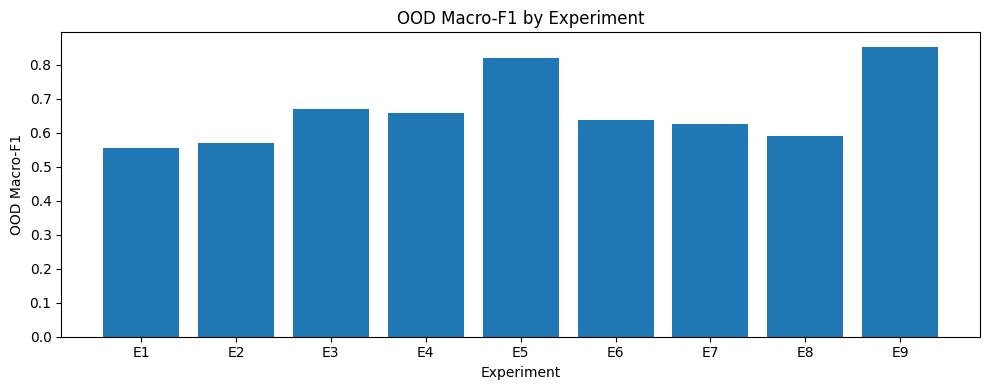

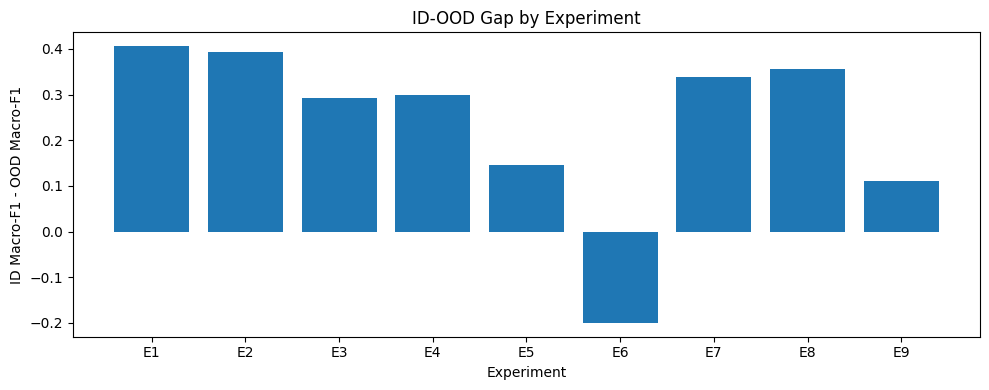

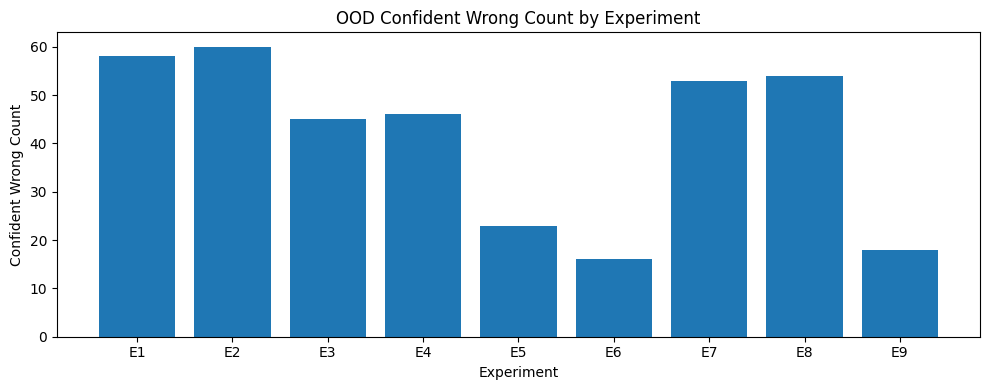

In [54]:
plot_df = comparison_df.dropna(subset=["ood_macro_f1"]).copy()

plt.figure(figsize=(10, 4))
plt.bar(plot_df["experiment_id"], plot_df["ood_macro_f1"])
plt.title("OOD Macro-F1 by Experiment")
plt.xlabel("Experiment")
plt.ylabel("OOD Macro-F1")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ood_macro_f1_by_experiment.png", dpi=200, bbox_inches="tight")
plt.show()


gap_df = comparison_df.dropna(subset=["id_ood_gap"]).copy()

plt.figure(figsize=(10, 4))
plt.bar(gap_df["experiment_id"], gap_df["id_ood_gap"])
plt.title("ID-OOD Gap by Experiment")
plt.xlabel("Experiment")
plt.ylabel("ID Macro-F1 - OOD Macro-F1")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "id_ood_gap_by_experiment.png", dpi=200, bbox_inches="tight")
plt.show()


cw_df = comparison_df.dropna(subset=["ood_confident_wrong_count"]).copy()

plt.figure(figsize=(10, 4))
plt.bar(cw_df["experiment_id"], cw_df["ood_confident_wrong_count"])
plt.title("OOD Confident Wrong Count by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Confident Wrong Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "ood_confident_wrong_count_by_experiment.png", dpi=200, bbox_inches="tight")
plt.show()

# 23. Best Model Summary

In [55]:
print_experiment_header("Best Model Summary")

if comparison_df["ood_macro_f1"].notna().any():
    best_ood = comparison_df.sort_values("ood_macro_f1", ascending=False).head(1)
    print("Best model by OOD Macro-F1:")
    display(best_ood)

if comparison_df["id_ood_gap"].notna().any():
    best_gap = comparison_df.sort_values("id_ood_gap", ascending=True).head(1)
    print("Best model by lowest ID-OOD gap:")
    display(best_gap)

if comparison_df["ood_confident_wrong_count"].notna().any():
    best_cw = comparison_df.sort_values("ood_confident_wrong_count", ascending=True).head(1)
    print("Best model by lowest confident wrong count:")
    display(best_cw)



  Best Model Summary
Best model by OOD Macro-F1:


,experiment_id,experiment_name,id_accuracy,id_macro_f1,ood_accuracy,ood_macro_f1,id_ood_gap,ood_confident_wrong_count
8,E9,NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation,0.963145,0.963056,0.853333,0.853307,0.109748,18


Best model by lowest ID-OOD gap:


,experiment_id,experiment_name,id_accuracy,id_macro_f1,ood_accuracy,ood_macro_f1,id_ood_gap,ood_confident_wrong_count
5,E6,NLI Zero-Shot,0.520885,0.438374,0.64,0.638393,-0.200018,16


Best model by lowest confident wrong count:


,experiment_id,experiment_name,id_accuracy,id_macro_f1,ood_accuracy,ood_macro_f1,id_ood_gap,ood_confident_wrong_count
5,E6,NLI Zero-Shot,0.520885,0.438374,0.64,0.638393,-0.200018,16


# 24. Display Saved Plots

Final plots:
results/plots/E1_id_confusion_matrix.png


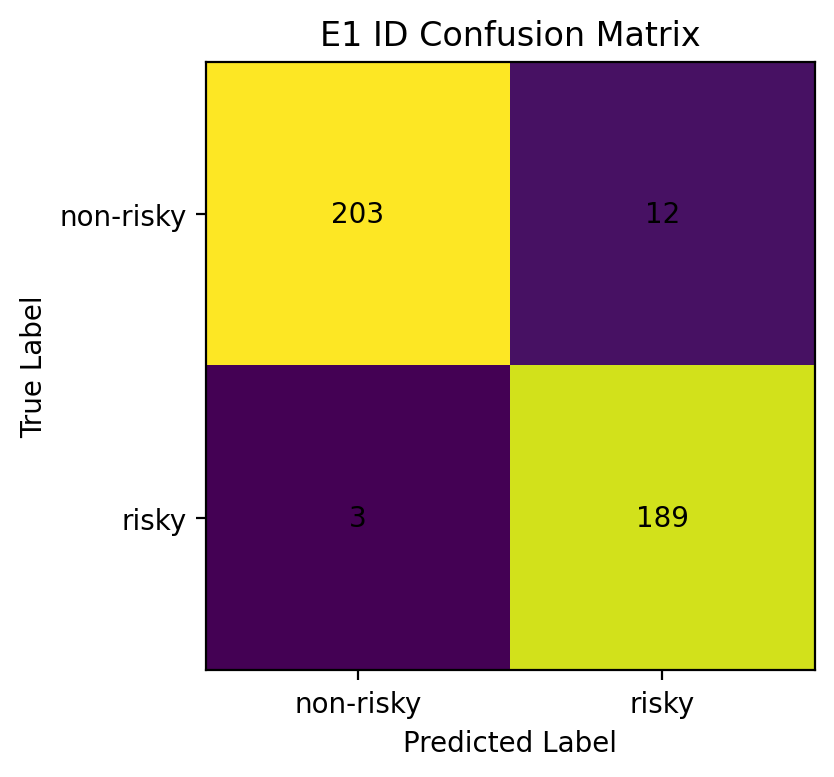

results/plots/E1_ood_confusion_matrix.png


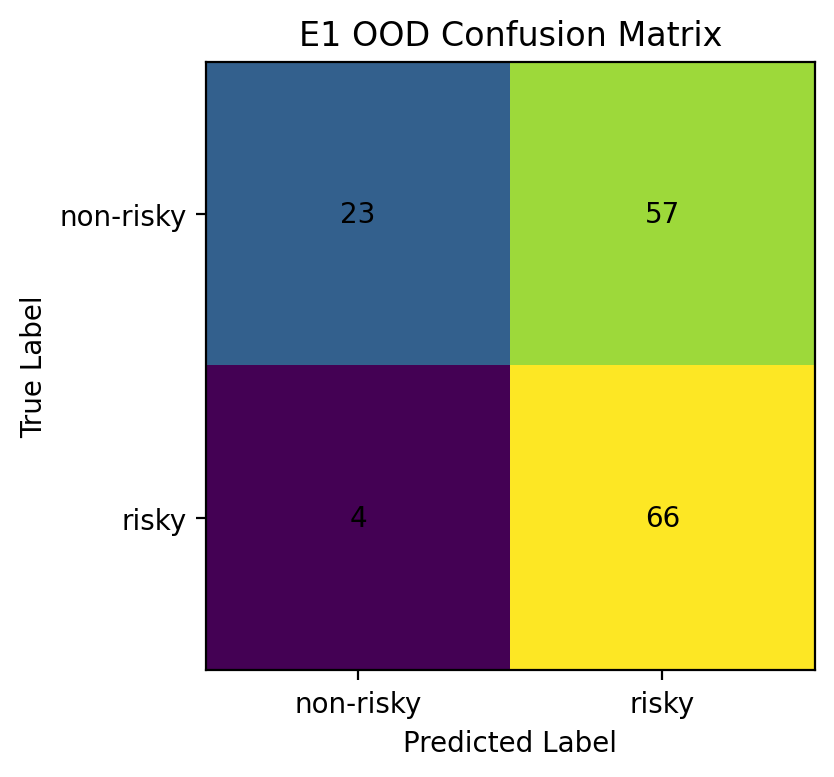

results/plots/E2_id_confusion_matrix.png


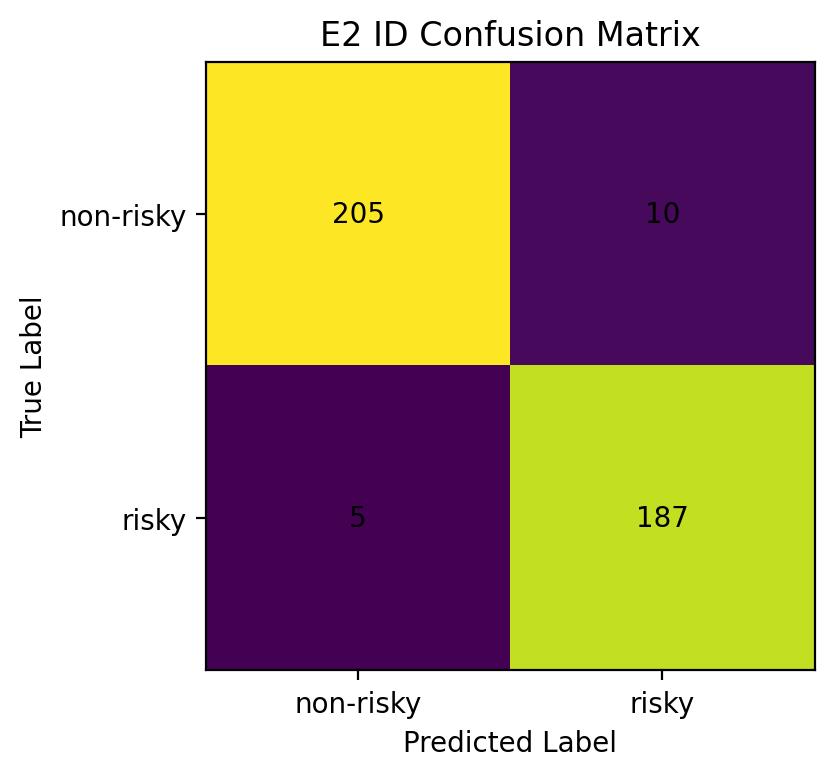

results/plots/E2_ood_confusion_matrix.png


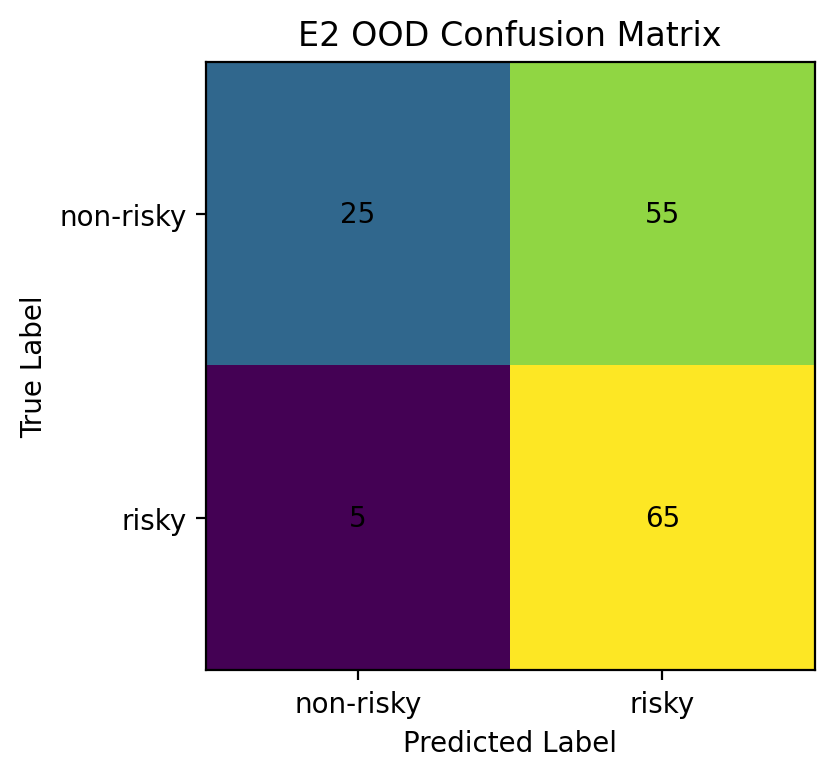

results/plots/E3_id_confusion_matrix.png


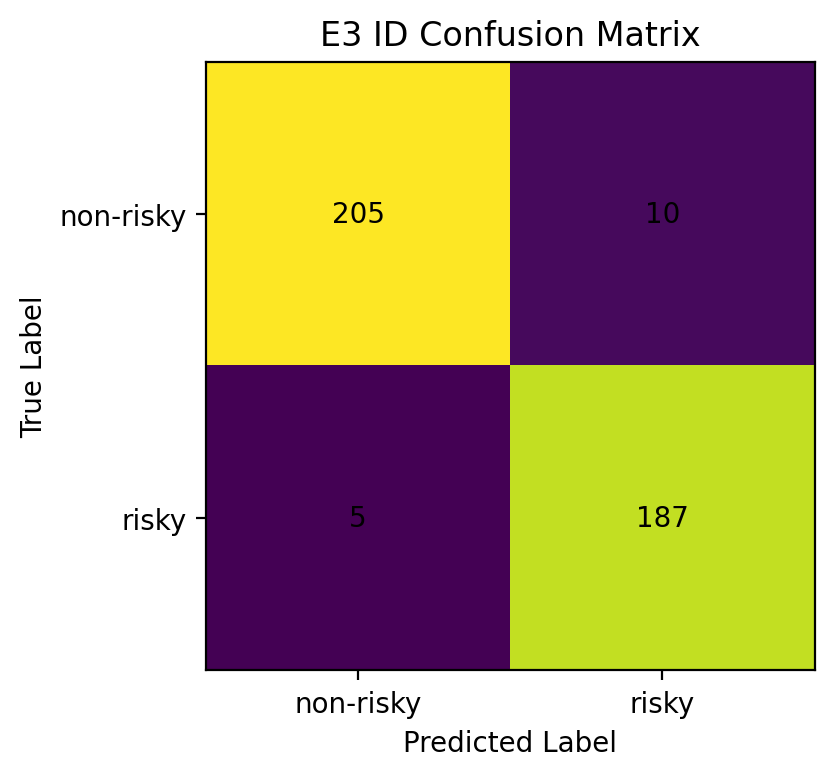

results/plots/E3_ood_confusion_matrix.png


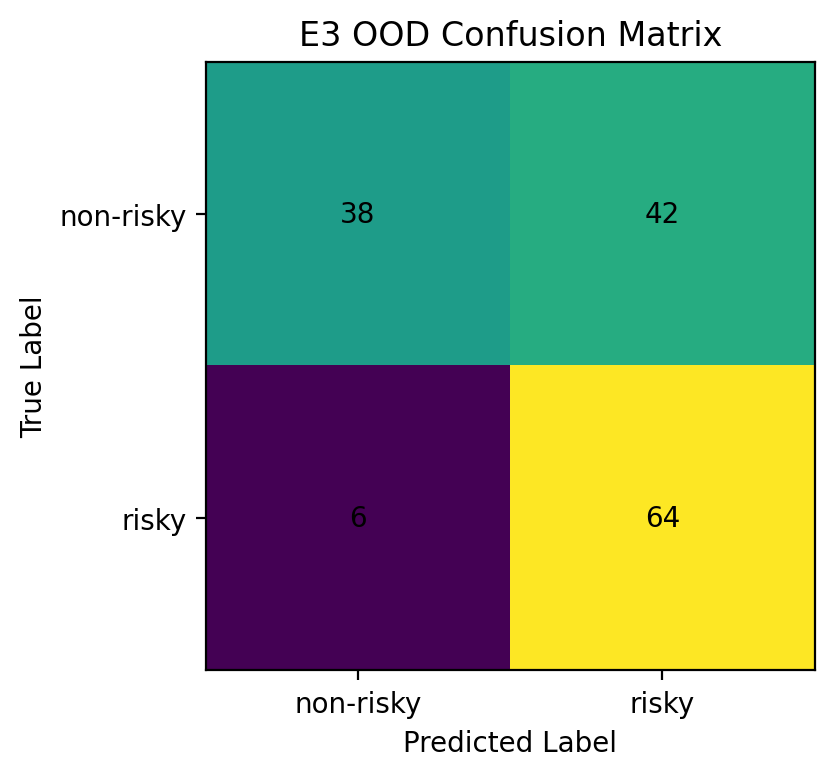

results/plots/E4_id_confusion_matrix.png


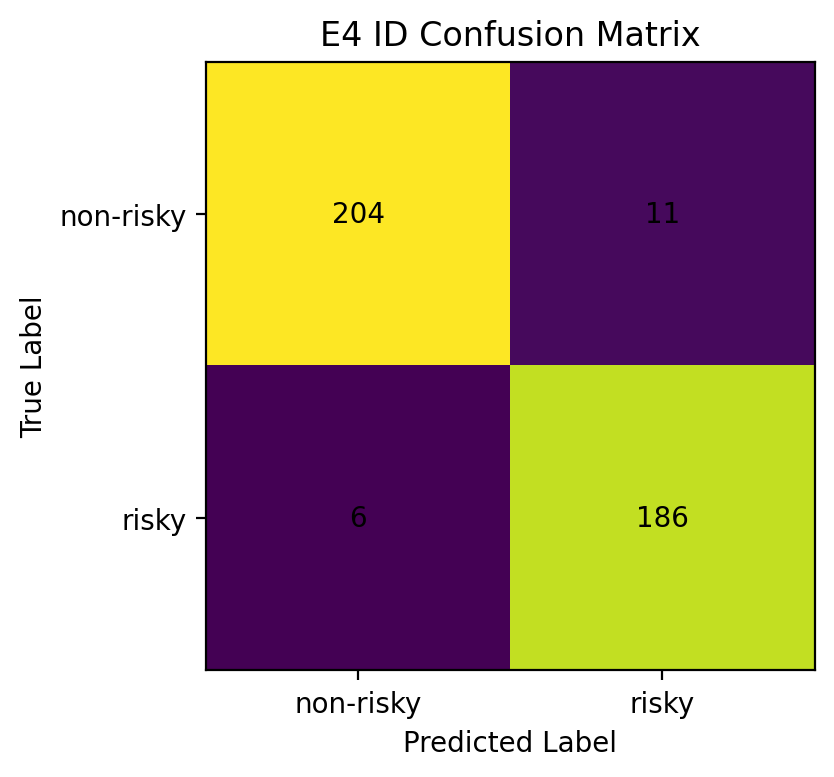

results/plots/E4_ood_confusion_matrix.png


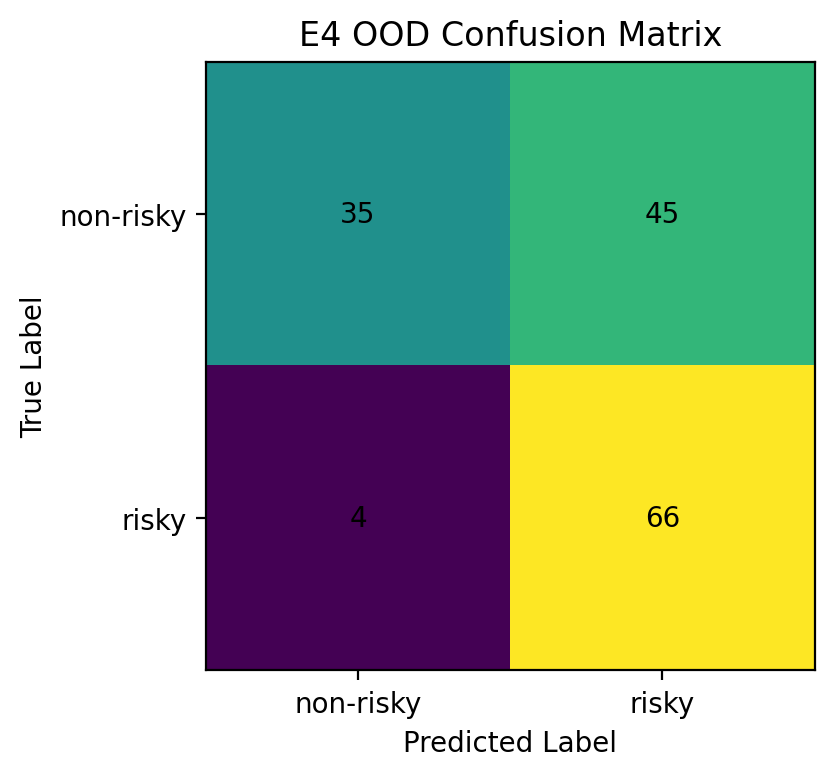

results/plots/E5_id_confusion_matrix.png


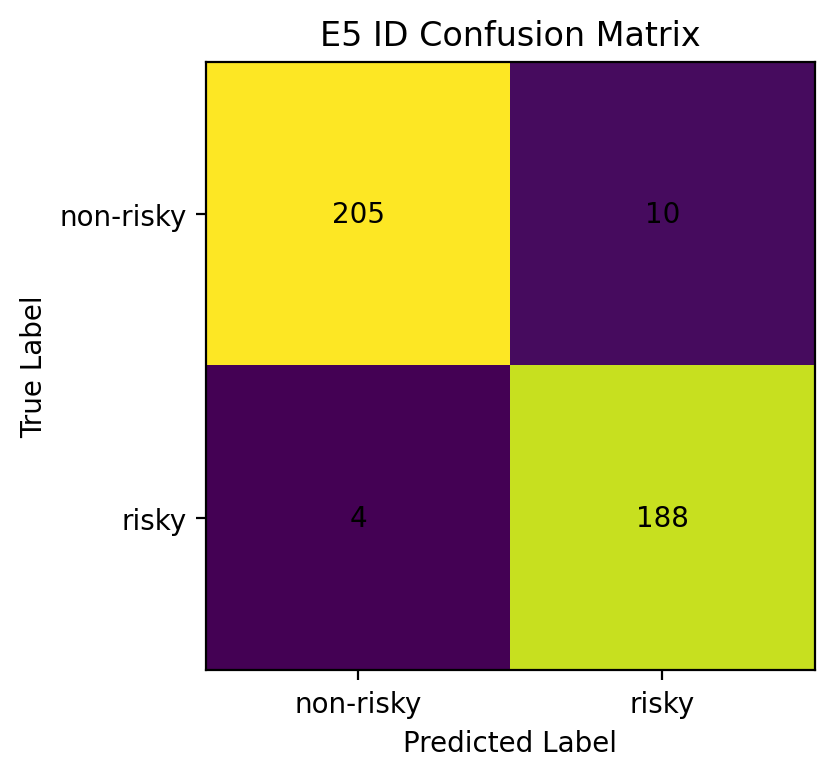

results/plots/E5_ood_confusion_matrix.png


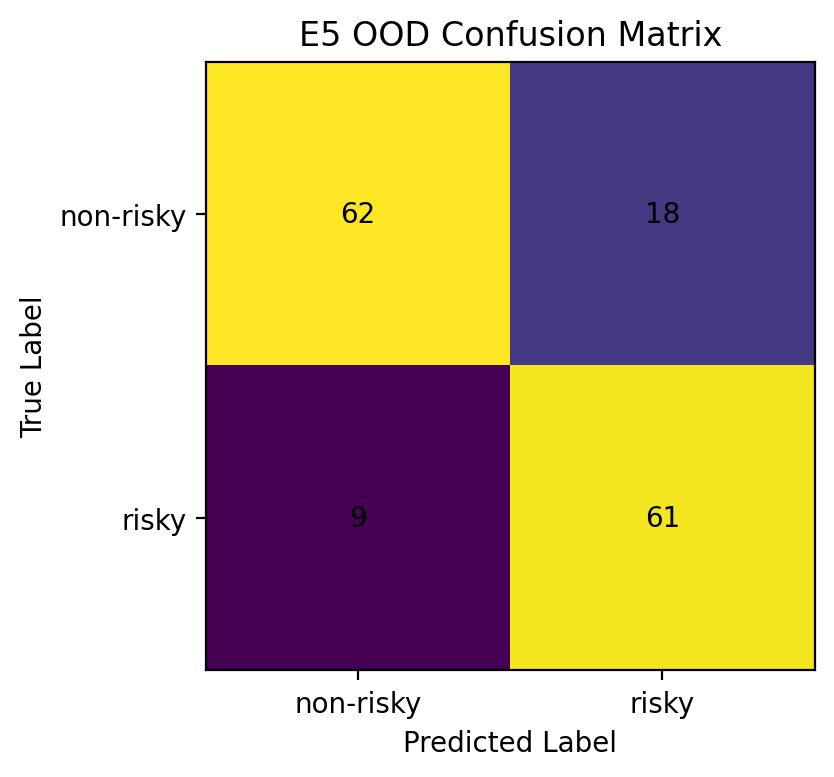

results/plots/E6_id_confusion_matrix.png


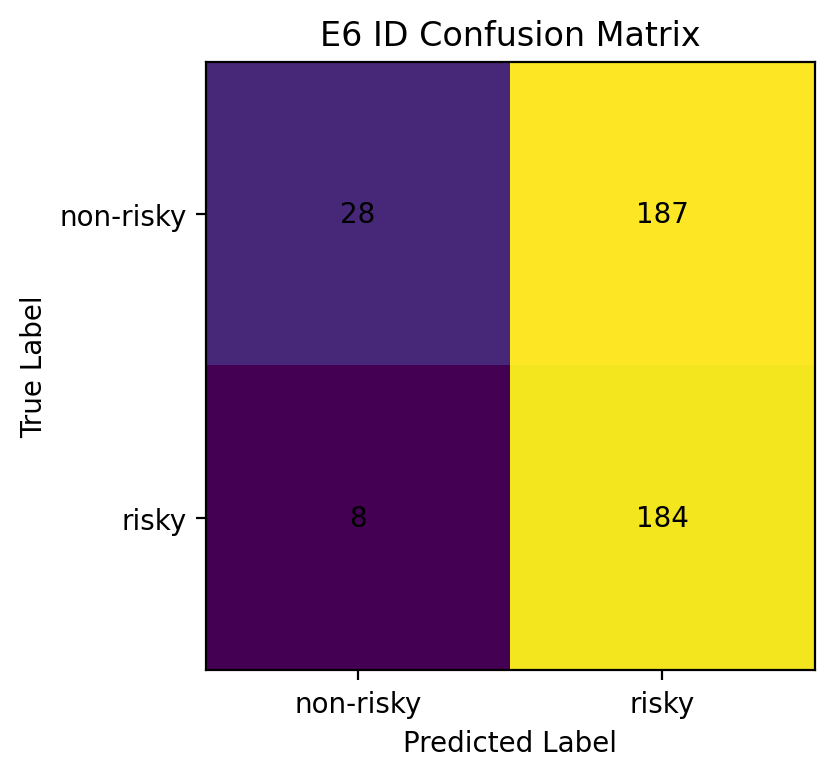

results/plots/E6_ood_confusion_matrix.png


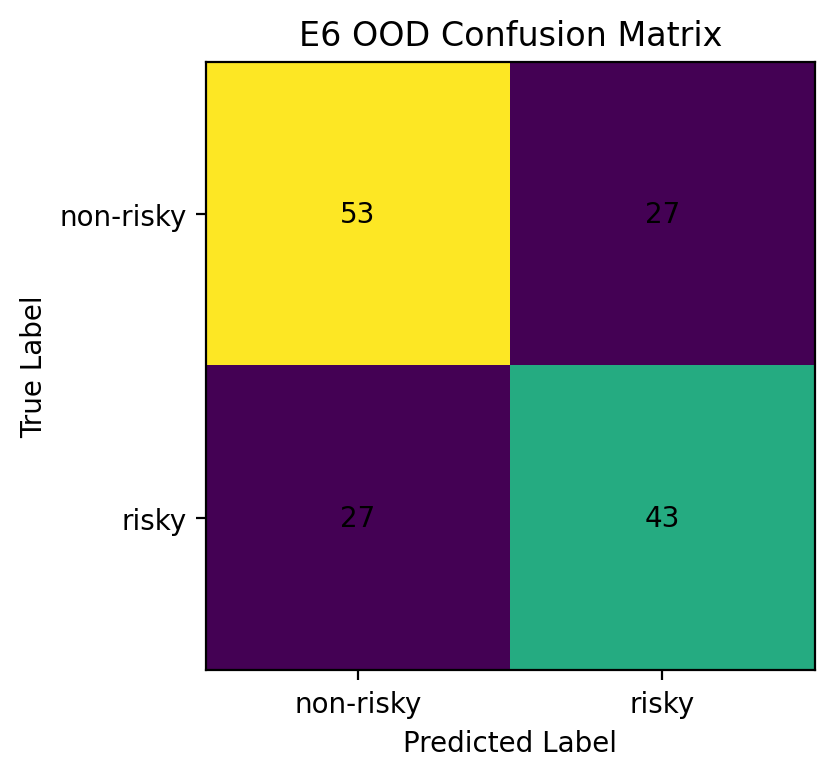

results/plots/E7_id_confusion_matrix.png


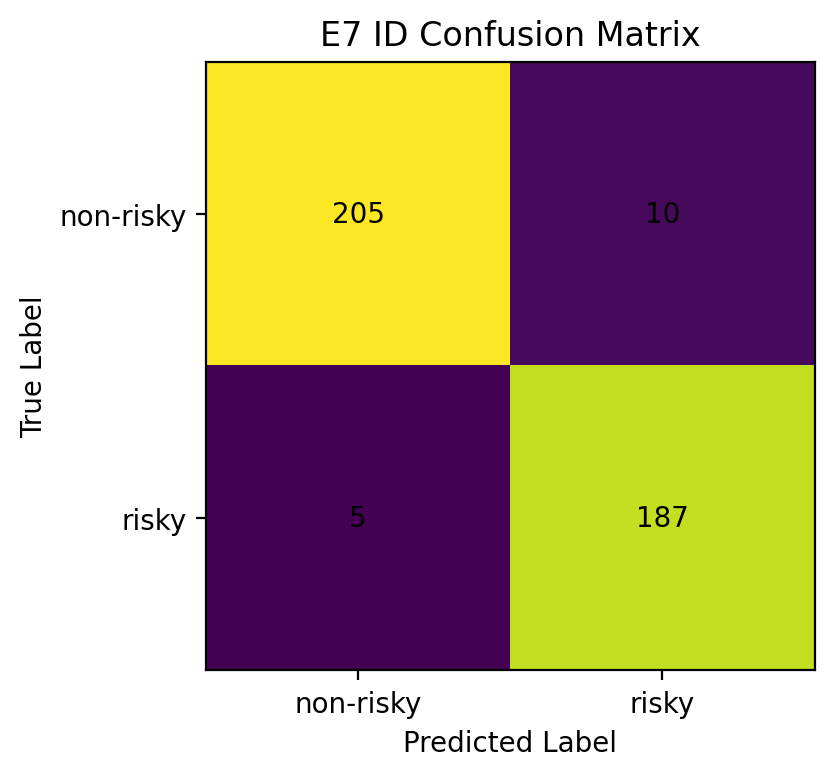

results/plots/E7_ood_confusion_matrix.png


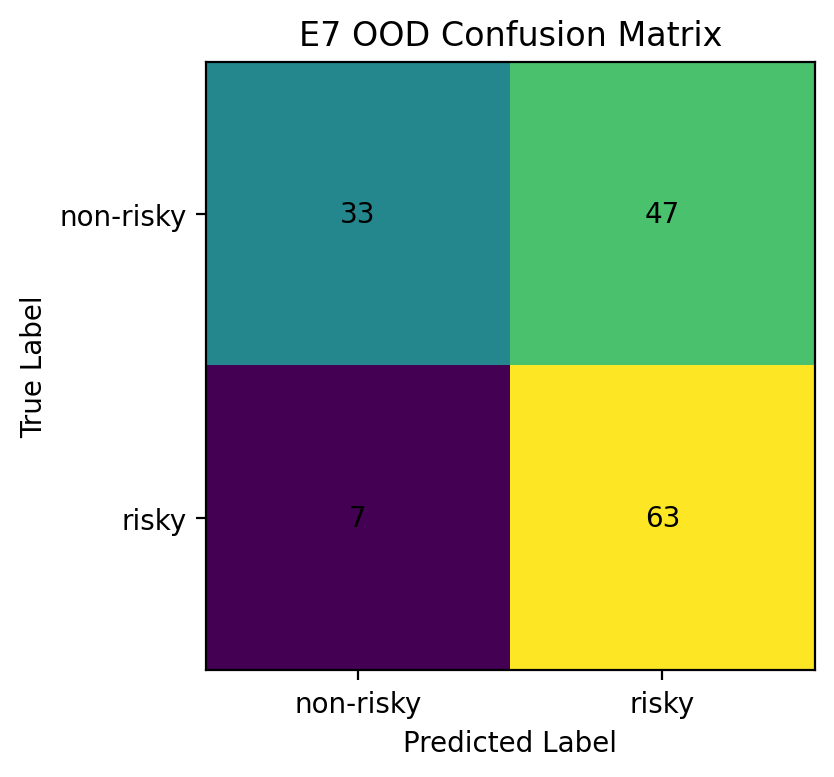

results/plots/E8_id_confusion_matrix.png


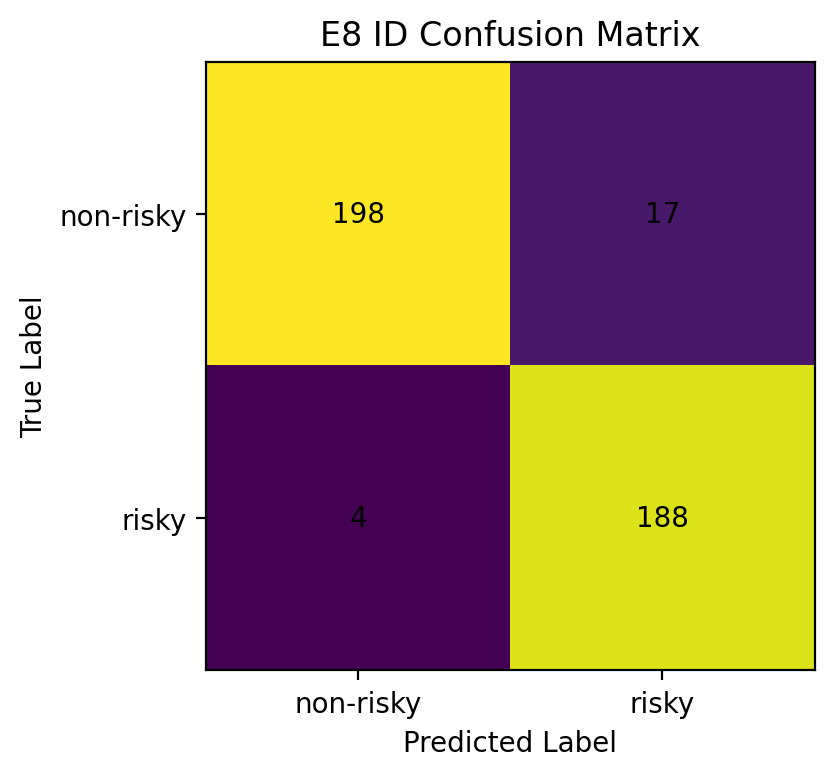

results/plots/E8_ood_confusion_matrix.png


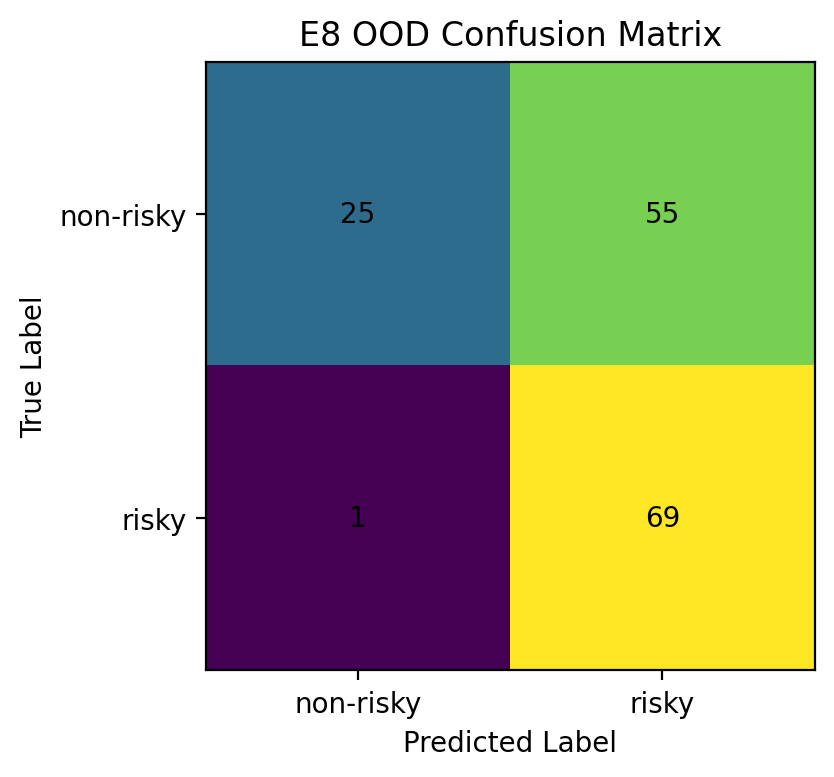

results/plots/E9_id_confusion_matrix.png


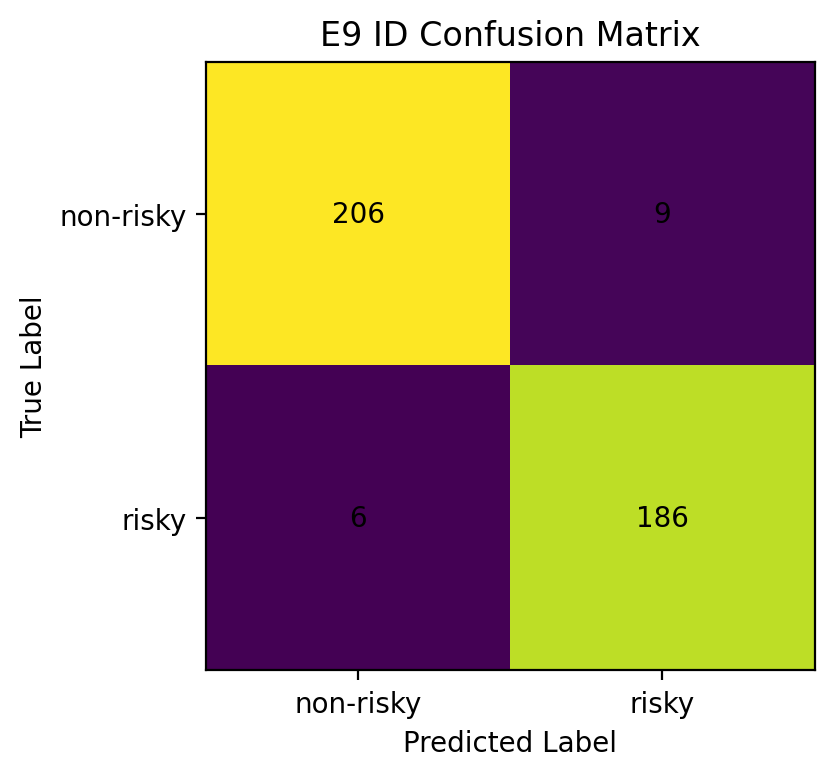

results/plots/E9_ood_confusion_matrix.png


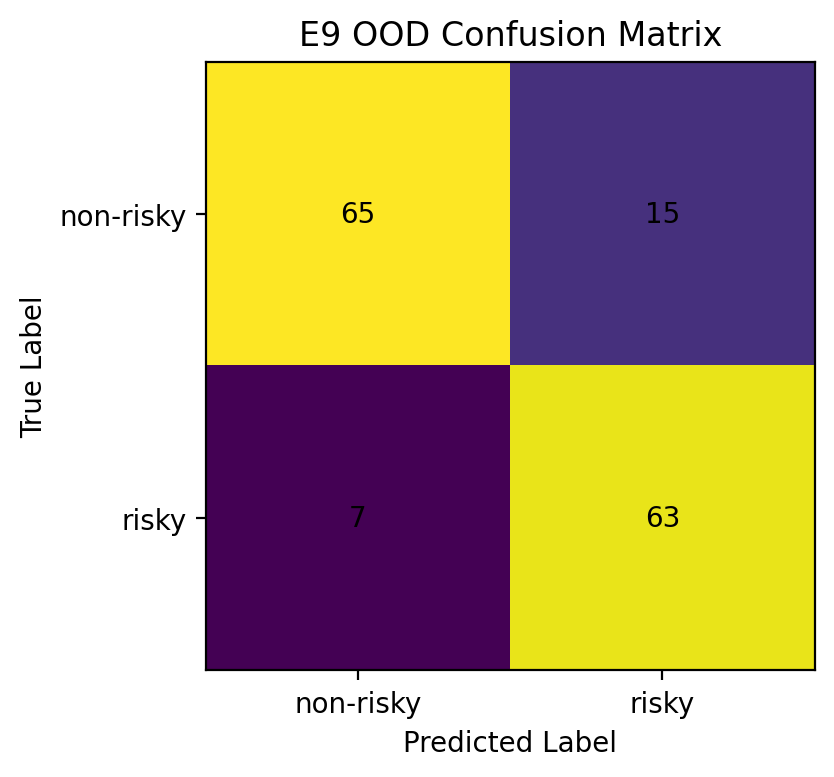

results/plots/id_ood_gap_by_experiment.png


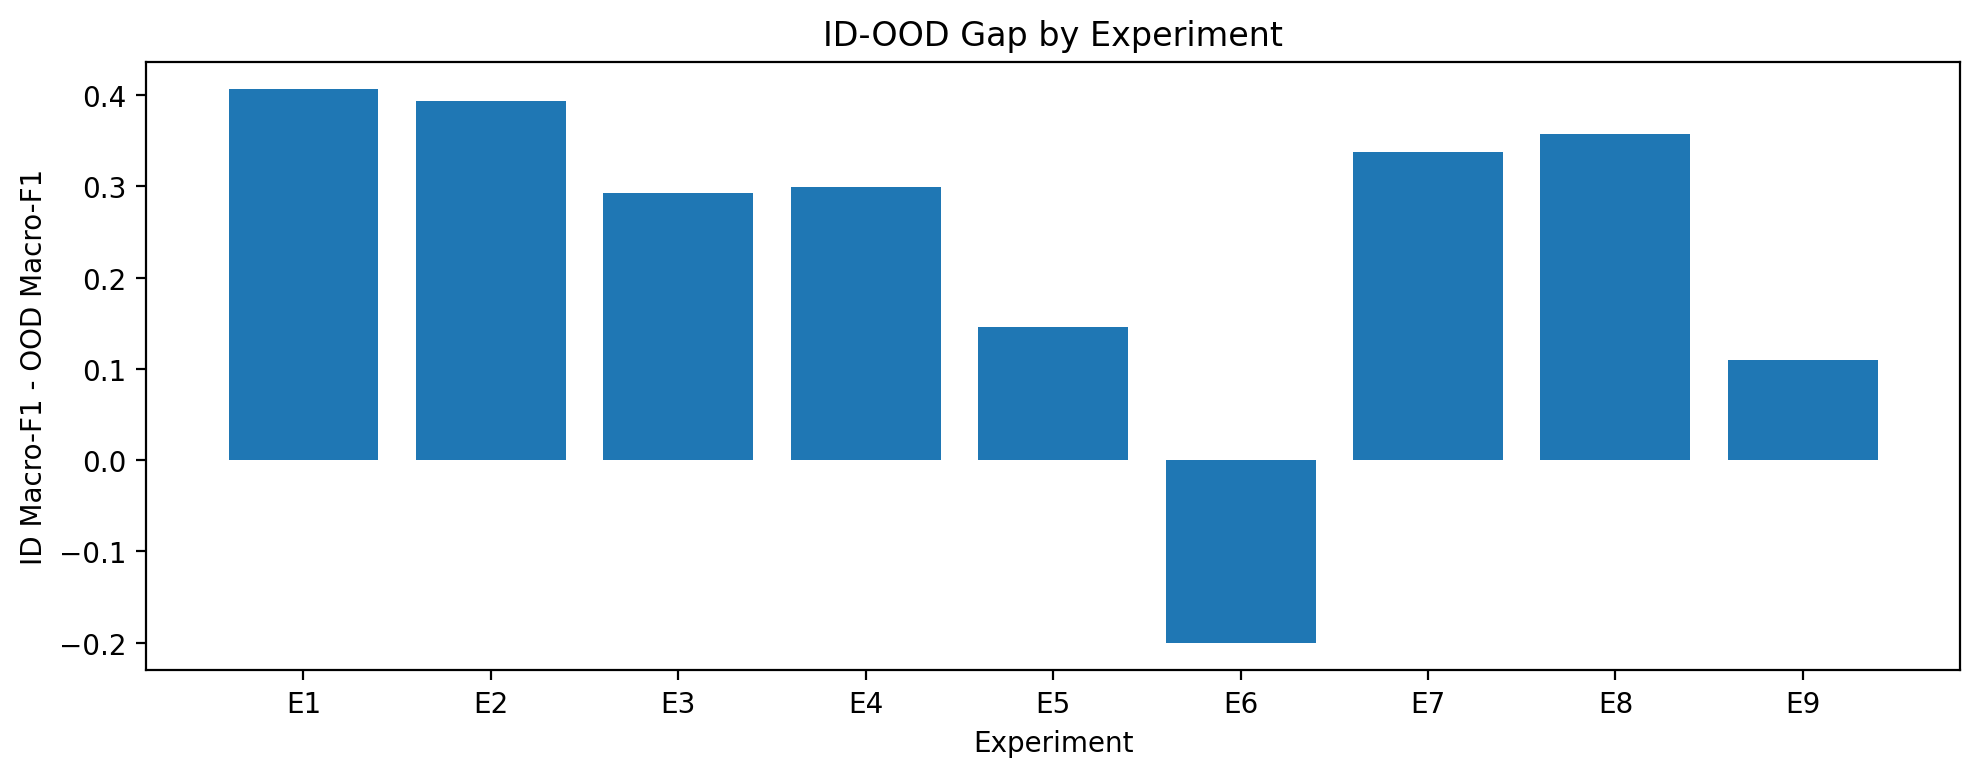

results/plots/ood_confident_wrong_count_by_experiment.png


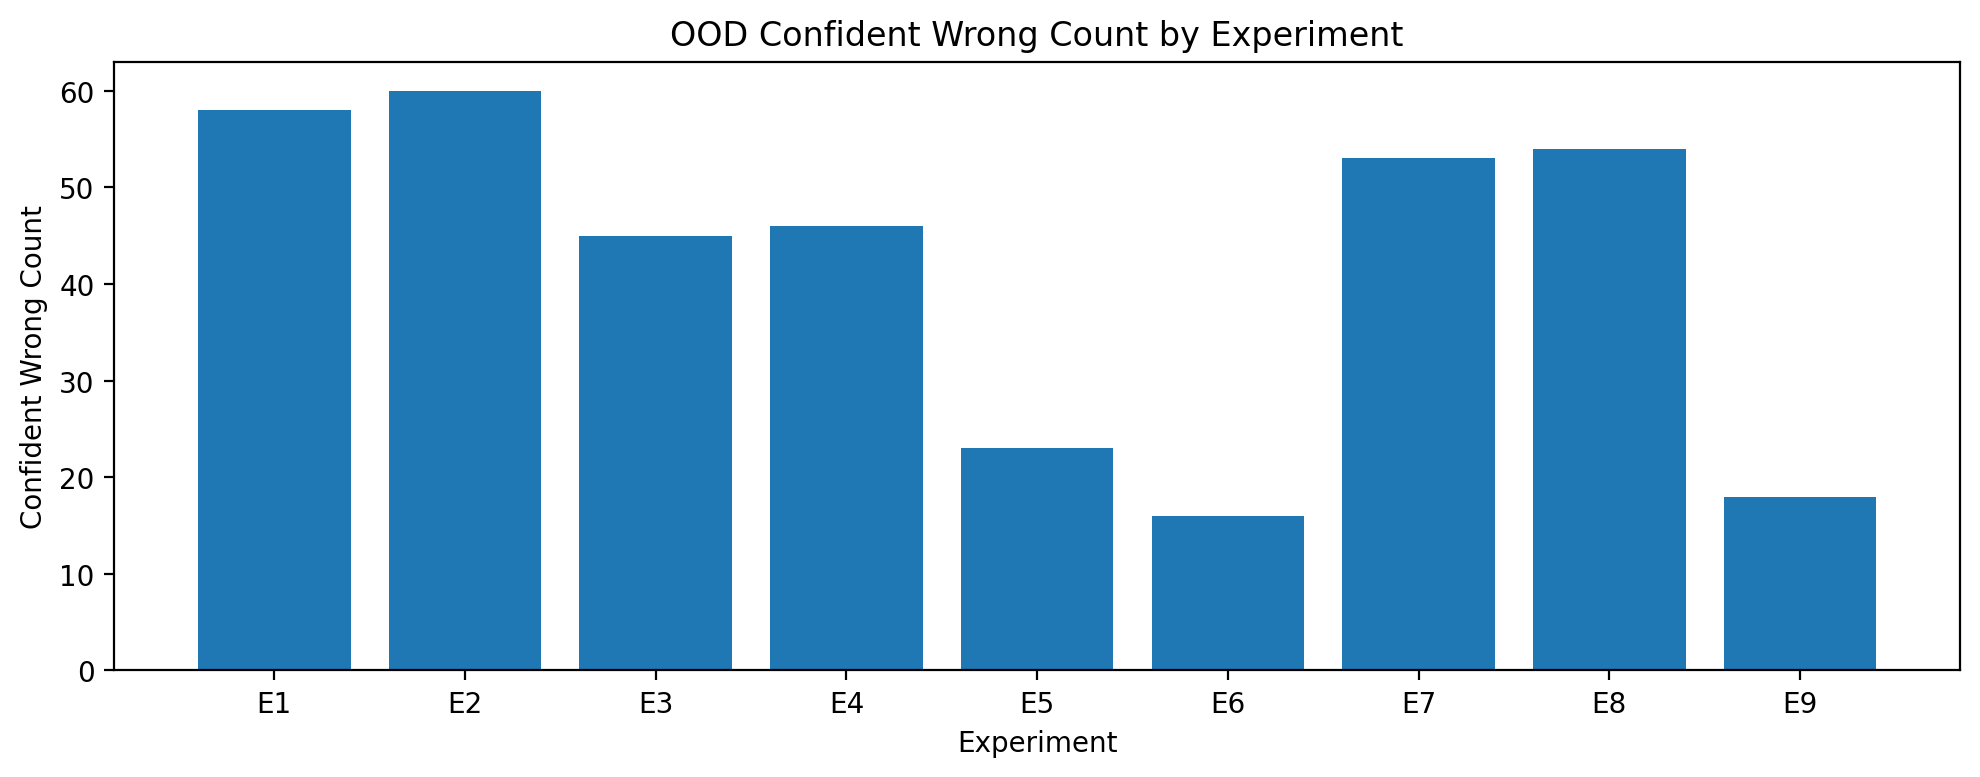

results/plots/ood_macro_f1_by_experiment.png


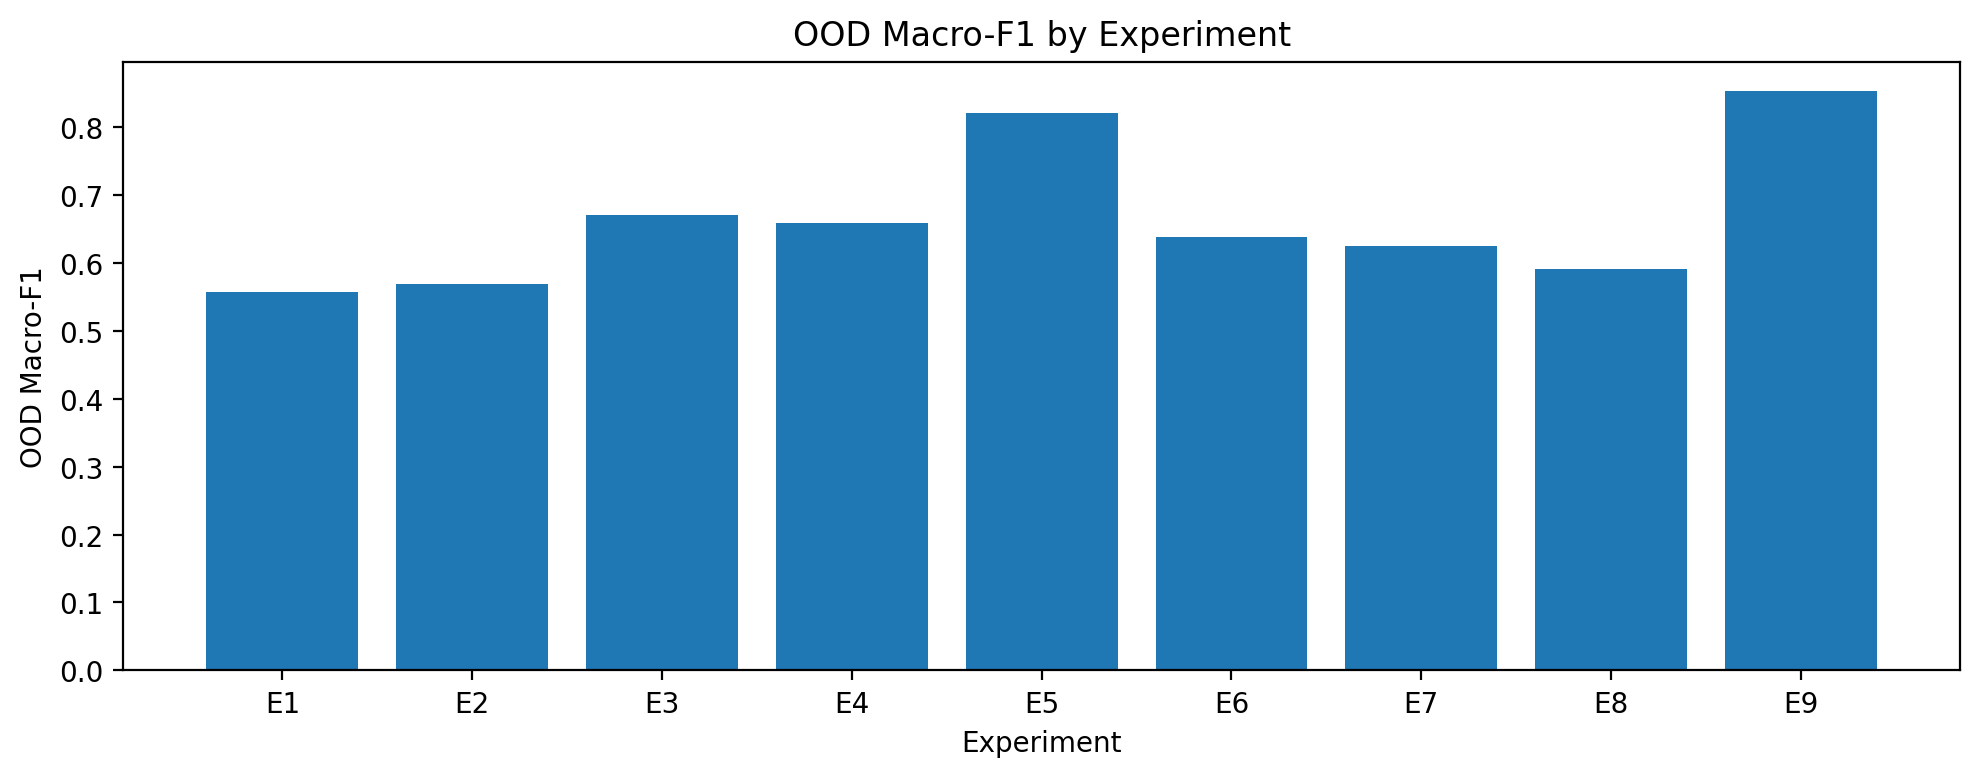

In [56]:
def display_all_pngs(folder):
    folder = Path(folder)

    if not folder.exists():
        print(f"Folder does not exist: {folder}")
        return

    png_files = sorted(folder.glob("*.png"))

    if not png_files:
        print(f"No PNG files found in {folder}")
        return

    for img_path in png_files:
        print(img_path)
        display(Image(filename=str(img_path)))


print("Final plots:")
display_all_pngs(PLOTS_DIR)